# 2-Stage 딥페이크 음성 탐지 시스템
## Multi-Feature Extraction + Temporal Sequence Modeling

### 연구 배경 및 동기

기존 1-Stage 모델(AttentionAudioClassifier)은 각 오디오 파일에서 MFCC 13차원의
**시간축 평균(mean pooling)** 벡터 하나만을 추출하여 분류에 사용했다.
이 방식은 시간적 변화 패턴(temporal dynamics)을 완전히 소실시킨다.

딥페이크 음성과 실제 음성의 핵심 차이는 **시간축 상의 미세한 불일치**에 있다:
- TTS 음성: 프로소디(운율)의 부자연스러운 전이, 포먼트 궤적의 비연속성
- Voice Conversion: 변환 과정에서 발생하는 프레임 간 불연속적 아티팩트
- 실제 음성: 자연스러운 코아티큘레이션(co-articulation)과 연속적 스펙트럴 변이

### 2-Stage 아키텍처 설계 철학

**Stage 1 (Feature Extractor):**
기존 학습된 AttentionAudioClassifier의 분류 헤드를 제거하고,
SE-Attention이 적용된 중간 표현(256차원 벡터)을 프레임 단위로 추출한다.
추가로, MFCC 외에 LFCC, Mel-Spectrogram, Spectral Contrast, Delta/Delta-Delta 등
다양한 음향 특징을 병렬로 추출하여 멀티-뷰 표현을 구성한다.

**Stage 2 (Temporal Classifier):**
프레임 단위 임베딩 시퀀스를 Transformer Encoder 또는 BiLSTM에 입력하여
시간적 패턴을 학습한다. 참고 논문:
- Xie et al. (2024) EAT: ResNet + Transformer Encoder + BiLSTM 결합
- LSTM-AE-DRDE (2025): Attention-enhanced LSTM with contrastive learning
- DK-CAST (2025): Multi-level supervision including embeddings and phoneme posteriors
- DLSA (2025): MFCC + CQT 2-stage MHA fusion, ASVspoof 2019 LA EER 0.68%

### 참고 문헌
1. Todisco et al., "ASVspoof 2019: Future horizons in spoofed and fake audio detection," 2019
2. Xie et al., "EAT: ResNet + Transformer + BiLSTM framework," 2024
3. Zaman et al., "Hybrid transformer architectures with diverse audio features," IEEE Access, 2024
4. Zhang et al., "Audio deepfake detection: what has been achieved and what lies ahead," Sensors, 2025
5. LSTM-AE-DRDE, "LSTM autoencoder with dynamic residual encoding," Scientific Reports, 2025
6. Shaaban, "Audio Deepfake Detection Using Deep Learning (Siamese CNN)," Engineering Reports, 2025
7. DLSA, "Spoof detection with dynamic learnable sparse attention and tri-modal fusion," PLOS ONE, 2025
8. DK-CAST, "Dynamic knowledge condensation with audio-selective transformer," Discover Computing, 2025
9. Deepfake voice detection with E2E transformer and acoustic feature fusion, Electronics, 2025


---
## 셀 1: 라이브러리 임포트 및 전역 설정

In [1]:
import os
import sys
import math
import copy
import warnings
import numpy as np
import librosa
import soundfile as sf
from pathlib import Path
from glob import glob
from tqdm import tqdm
from collections import Counter, OrderedDict

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import (
    Dataset, DataLoader, WeightedRandomSampler, TensorDataset
)
from torch.nn.utils.rnn import pad_sequence, pack_padded_sequence, pad_packed_sequence

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    f1_score, roc_auc_score
)
from imblearn.over_sampling import SMOTE

import matplotlib.pyplot as plt
import seaborn as sns
import joblib

warnings.filterwarnings('ignore')

# ==============================================================
# 전역 설정
# ==============================================================
# [수정] 데이터셋 경로 - 실제 폴더명 'DATASET'으로 변경
# 폴더 구조: DATASET/{train,val,test}/{real,fake}/*.wav
BASE_DIR = 'DATASET'

# [수정] 클래스 수 상수 - 데이터셋이 real/fake 2-class로 변경됨
# 기존: 3-class (real/fake/tts) 였으나 데이터셋에 tts 폴더 없음
# 노트북 전체에서 이 상수를 참조하도록 통일
NUM_CLASSES = 2

# 오디오 전처리 파라미터
SAMPLE_RATE = 16000       # ASVspoof 표준 샘플링 레이트
SEGMENT_LENGTH = 4.0
OVERLAP = 0.25

# 특징 추출 파라미터
N_MFCC = 13               # MFCC 계수 (ASVspoof 표준)
N_LFCC = 20               # LFCC 계수 (고주파 해상도가 더 높으므로 MFCC보다 많이 사용)
N_MELS = 40               # Mel-Spectrogram 필터뱅크 수
N_FFT = 512               # FFT 윈도우 (32ms at 16kHz)
HOP_LENGTH = 160           # 홉 길이 (10ms at 16kHz, ASVspoof 표준)
WIN_LENGTH = 400           # 윈도우 길이 (25ms at 16kHz)

# 시퀀스 모델링 파라미터
MAX_SEQ_LEN = 400         # 최대 프레임 수 (4초 / 10ms = 400)
FRAME_EMBEDDING_DIM = 256 # Stage 1 출력 임베딩 차원

# 학습 파라미터
BATCH_SIZE = 64
NUM_EPOCHS = 100
LEARNING_RATE = 1e-4
WEIGHT_DECAY = 1e-4
PATIENCE = 20

# 시드 고정
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

# [수정] device 선언을 cell 2에 통합
# 기존: cell 6에서 처음 device 정의 - cell 8 실행 시 device 미정의 위험
# 수정: 전역 설정 셀에서 한 번만 정의하고 이후 셀에서 공통 사용
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

if torch.cuda.is_available():
    # [수정] TF32 활성화 (Ampere 이후 GPU에서 FP32 대비 속도 향상)
    # RTX 4070 Ti(Ada Lovelace) 등에서 행렬/conv 연산 가속
    # 정확도 손실 거의 없음 (mantissa 10bit)
    torch.backends.cuda.matmul.allow_tf32 = True
    torch.backends.cudnn.allow_tf32 = True

print(f"PyTorch   : {torch.__version__}")
print(f"device    : {device}")
if torch.cuda.is_available():
    print(f"GPU       : {torch.cuda.get_device_name(0)}")
    print(f"CUDA ver  : {torch.version.cuda}")
    print(f"VRAM      : {torch.cuda.get_device_properties(0).total_memory / 1024**3:.2f} GB")
    print(f"TF32      : {torch.backends.cuda.matmul.allow_tf32}")


PyTorch   : 2.5.1
device    : cuda
GPU       : NVIDIA GeForce RTX 4070 Ti
CUDA ver  : 12.1
VRAM      : 11.99 GB
TF32      : True


---
## 셀 2: 다중 음향 특징 추출 함수 정의

교수님 피드백: "MFCC 특징 외에 다른 특징들도 함께 고려해도 좋을 것 같아요"

각 특징이 포착하는 음향적 성질:

### MFCC (Mel-Frequency Cepstral Coefficients)
- **물리적 의미**: 인간 청각의 비선형 주파수 감도(mel scale)를 반영한 스펙트럼 포락선
- **딥페이크 탐지 관련성**: 보코더가 생성하는 멜 필터뱅크 출력의 과도한 평활화를 감지
- **한계**: 고주파 대역(4kHz 이상)의 해상도가 낮아 보코더 아티팩트 포착이 제한적

### LFCC (Linear-Frequency Cepstral Coefficients)
- **물리적 의미**: 선형 주파수 스케일의 필터뱅크 기반 캡스트럼 계수
- **딥페이크 탐지 관련성**: MFCC와 달리 고주파 대역을 균등하게 커버하여
  neural vocoder의 고주파 아티팩트(금속성 잡음, 앨리어싱)를 더 잘 포착
- **근거**: ASVspoof 2019/2021에서 LFCC가 MFCC보다 일관적으로 우수한 성능 기록

### Mel-Spectrogram
- **물리적 의미**: 시간-주파수 에너지 분포를 멜 스케일로 압축한 2D 표현
- **딥페이크 탐지 관련성**: 프레임 간 에너지 전이의 연속성/불연속성을 보존

### Spectral Contrast
- **물리적 의미**: 각 서브밴드에서 스펙트럼 피크와 밸리의 에너지 차이
- **딥페이크 탐지 관련성**: 실제 음성은 하모닉 구조로 높은 콘트라스트,
  보코더 합성 음성은 스펙트럼이 더 평탄하여 콘트라스트가 낮은 경향

### Delta 및 Delta-Delta (시간 미분 계수)
- **물리적 의미**: 특징의 1차/2차 시간 미분, 즉 변화 속도와 가속도
- **딥페이크 탐지 관련성**: TTS 음성의 부자연스럽게 매끄러운 전이 vs 실제 음성의 자연스러운 변동
- **근거**: ASVspoof 기본 시스템에서 MFCC + Delta + Delta-Delta 조합이 표준


In [2]:
def compute_lfcc(y, sr, n_lfcc=N_LFCC, n_fft=N_FFT,
                 hop_length=HOP_LENGTH, win_length=WIN_LENGTH):
    # LFCC (Linear Frequency Cepstral Coefficients) 추출
    #
    # MFCC가 멜 스케일(로그 주파수)을 사용하는 반면,
    # LFCC는 선형 주파수 스케일의 필터뱅크를 사용한다.
    #
    # 이론적 배경:
    #   선형 필터뱅크는 모든 주파수 대역을 균등한 대역폭으로 커버한다.
    #   따라서 고주파 대역(4kHz~8kHz)의 해상도가 MFCC보다 높다.
    #   Neural vocoder(WaveNet, WaveRNN, HiFi-GAN 등)는 고주파 대역에서
    #   앨리어싱, 금속성 노이즈, 부자연스러운 감쇠 등의 아티팩트를 남긴다.
    #   LFCC는 이러한 고주파 아티팩트를 더 정밀하게 포착할 수 있다.
    #
    # 구현:
    #   1. STFT -> 파워 스펙트로그램
    #   2. 선형 주파수 간격 삼각 필터뱅크 적용 (멜 스케일 대신)
    #   3. 로그 에너지 계산
    #   4. DCT로 캡스트럴 계수 추출
    #
    # 반환: (n_lfcc, T) 형태의 LFCC 행렬

    from scipy.fft import dct

    # 파워 스펙트로그램
    S = np.abs(librosa.stft(y, n_fft=n_fft, hop_length=hop_length,
                            win_length=win_length)) ** 2

    # 선형 주파수 간격 필터뱅크 생성
    n_filters = n_lfcc * 2
    freq_bins = n_fft // 2 + 1
    fmin = 0
    fmax = sr / 2

    # 선형 간격 중심 주파수 (멜 필터뱅크와의 핵심 차이)
    center_freqs = np.linspace(fmin, fmax, n_filters + 2)
    bin_indices = np.floor((n_fft + 1) * center_freqs / sr).astype(int)

    # 삼각 필터뱅크 구성
    filterbank = np.zeros((n_filters, freq_bins))
    for i in range(n_filters):
        left = bin_indices[i]
        center = bin_indices[i + 1]
        right = bin_indices[i + 2]
        if center > left:
            filterbank[i, left:center] = (
                np.arange(left, center) - left
            ) / (center - left)
        if right > center:
            filterbank[i, center:right] = (
                right - np.arange(center, right)
            ) / (right - center)

    # 필터뱅크 적용 -> 로그 -> DCT
    filter_energies = np.dot(filterbank, S)
    log_energies = np.log(filter_energies + 1e-10)
    lfcc = dct(log_energies, type=2, axis=0, norm='ortho')[:n_lfcc]

    return lfcc


def extract_multi_features_per_frame(audio_path, sr=SAMPLE_RATE,
                                      max_frames=MAX_SEQ_LEN):
    # 하나의 오디오 파일에서 프레임 단위 다중 특징 벡터를 추출한다.
    #
    # 추출되는 특징 (각 프레임 t에 대해):
    #   - MFCC (13D): 멜 스케일 스펙트럼 포락선
    #   - MFCC Delta (13D): 1차 시간 미분 (변화 속도)
    #     -> TTS는 파라미터 보간으로 delta가 비정상적으로 매끄러움
    #   - MFCC Delta-Delta (13D): 2차 시간 미분 (변화 가속도)
    #     -> 실제 음성은 코아티큘레이션으로 복잡한 가속 패턴
    #   - LFCC (20D): 선형 주파수 캡스트럼 (고주파 해상도 강화)
    #   - Mel-Spectrogram (40D): 멜 필터뱅크 에너지
    #   - Spectral Contrast (7D): 서브밴드 피크-밸리 에너지 차이
    #     -> 실제 음성은 하모닉 구조로 높은 콘트라스트,
    #        보코더 음성은 스펙트럼이 더 평탄하여 낮은 콘트라스트
    #   합계: 106차원 프레임 벡터
    #
    # 반환: (T, 106) numpy array 또는 None

    try:
        # [수정] duration=SEGMENT_LENGTH+0.5 상한 추가
        # 기존: librosa.load(audio_path, sr=sr, mono=True)
        # 문제: 파일 전체를 RAM에 올림
        #       shape (257, 1575) 같은 긴 파일이 STFT 중간 배열로
        #       수십 MiB를 할당하면서 MemoryError 발생
        # 수정: SEGMENT_LENGTH(4.0)+0.5초로 잘라 단일 파일 RAM 점유 상한 고정
        #       MAX_SEQ_LEN=400프레임(4초) 기준이므로 초과분은 어차피 잘림
        y, _ = librosa.load(
            audio_path, sr=sr, mono=True,
            duration=SEGMENT_LENGTH + 0.5
        )

        # 0.5초 미만 제외
        if len(y) < sr * 0.5:
            return None

        # MFCC: 멜 스케일 스펙트럼 포락선 (ASVspoof 표준 13차원)
        mfcc = librosa.feature.mfcc(
            y=y, sr=sr, n_mfcc=N_MFCC,
            n_fft=N_FFT, hop_length=HOP_LENGTH, win_length=WIN_LENGTH
        )  # (13, T)

        # MFCC Delta: 인접 프레임 변화율 (width=5: 전후 2프레임)
        mfcc_delta = librosa.feature.delta(mfcc, width=5)  # (13, T)

        # MFCC Delta-Delta: 변화율의 변화율 (가속도)
        mfcc_delta2 = librosa.feature.delta(mfcc, order=2, width=5)  # (13, T)

        # LFCC: 고주파 보코더 아티팩트 탐지용 선형 주파수 캡스트럼
        lfcc = compute_lfcc(y, sr)  # (20, T)

        # Mel-Spectrogram: 시간-주파수 에너지 분포
        mel_spec = librosa.feature.melspectrogram(
            y=y, sr=sr, n_mels=N_MELS,
            n_fft=N_FFT, hop_length=HOP_LENGTH, win_length=WIN_LENGTH
        )
        log_mel = librosa.power_to_db(mel_spec, ref=np.max)  # (40, T)

        # Spectral Contrast: 서브밴드 피크-밸리 에너지 차이
        # 하모닉 구조가 있는 실제 음성 = 높은 콘트라스트
        # 보코더 음성 = 스펙트럼이 더 평탄 = 낮은 콘트라스트
        spectral_contrast = librosa.feature.spectral_contrast(
            y=y, sr=sr, n_fft=N_FFT, hop_length=HOP_LENGTH,
            n_bands=6  # 6 서브밴드 + 1 밸리 = 7차원
        )  # (7, T)

        # 프레임 수 통일 (각 특징의 T가 약간 다를 수 있음)
        min_frames_count = min(
            mfcc.shape[1], lfcc.shape[1],
            log_mel.shape[1], spectral_contrast.shape[1]
        )

        mfcc = mfcc[:, :min_frames_count]
        mfcc_delta = mfcc_delta[:, :min_frames_count]
        mfcc_delta2 = mfcc_delta2[:, :min_frames_count]
        lfcc = lfcc[:, :min_frames_count]
        log_mel = log_mel[:, :min_frames_count]
        spectral_contrast = spectral_contrast[:, :min_frames_count]

        # 모든 특징 결합: (106, T)
        combined = np.concatenate([
            mfcc,               # 13: 멜 스케일 스펙트럼 포락선
            mfcc_delta,         # 13: 시간적 변화 속도
            mfcc_delta2,        # 13: 시간적 변화 가속도
            lfcc,               # 20: 선형 주파수 캡스트럼
            log_mel,            # 40: 멜 스펙트로그램 에너지
            spectral_contrast,  #  7: 서브밴드 피크-밸리 차이
        ], axis=0)

        # 전치: (T, 106) - 시퀀스 모델 입력 형식
        combined = combined.T

        # 시퀀스 길이 제한
        if combined.shape[0] > max_frames:
            combined = combined[:max_frames]

        return combined

    except Exception as e:
        print(f"특징 추출 오류 ({audio_path}): {e}")
        return None


# 특징 추출 함수 테스트
print("다중 특징 추출 함수 결과")
test_signal = np.random.randn(SAMPLE_RATE * 3)
sf.write(r'C:\Users\ipl\Desktop\test\DATASET\train\real\R_000000.wav', test_signal, SAMPLE_RATE)
test_features = extract_multi_features_per_frame(r'C:\Users\ipl\Desktop\test\DATASET\train\real\R_000000.wav')
if test_features is not None:
    print(f"  출력 형태: {test_features.shape}")
    print(f"  프레임 수 (T): {test_features.shape[0]}")
    print(f"  특징 차원 (D): {test_features.shape[1]}")
    feat_breakdown = "MFCC(13) + Delta(13) + Delta2(13) + LFCC(20) + Mel(40) + Contrast(7)"
    print(f"  특징 구성: {feat_breakdown} = {13+13+13+20+40+7}")


다중 특징 추출 함수 결과
  출력 형태: (301, 106)
  프레임 수 (T): 301
  특징 차원 (D): 106
  특징 구성: MFCC(13) + Delta(13) + Delta2(13) + LFCC(20) + Mel(40) + Contrast(7) = 106


---
## 셀 3: Stage 1 모델 정의 - 기존 AttentionAudioClassifier 기반 임베딩 추출기

교수님 피드백: "현재 모델을 통해 각 오디오 시퀀스를 벡터 형태로 만들고"

기존 학습된 AttentionAudioClassifier의 가중치를 재활용한다.
핵심: 분류 헤드(classifier)를 제거하고, SE-Attention이 적용된
중간 표현(256차원)을 각 프레임의 "음성 품질 임베딩"으로 사용한다.

이론적 근거:
1. **전이 학습**: 기존 모델이 학습한 판별적 표현을 시퀀스 모델 입력으로 활용
2. **SE 블록**: 이미 "딥페이크 탐지에 중요한 특징 채널"에 대한 어텐션을 학습
3. **2-Stage 분리**: 특징 추출과 시간적 모델링을 독립 최적화, 해석 가능성 향상

참고: DK-CAST (2025) 교사 모델 중간 표현 전이, Wav2Vec2 fine-tuning 접근법


In [3]:
# ================================================================
# Stage 1-A: 기존 모델 구조 정의 (가중치 로드용)
# ================================================================

class SEBlock(nn.Module):
    # Squeeze-and-Excitation 블록 (채널 어텐션, Hu et al., 2018)
    #
    # 각 채널의 글로벌 정보를 squeeze하고, 채널 간 상호의존성을 excitation으로 모델링.
    # 수식: z = GlobalAvgPool(x), s = sigmoid(W2 * ReLU(W1 * z)), output = x * s
    #
    # 딥페이크 탐지에서의 역할:
    #   MFCC 13개 계수 중 딥페이크 구분에 변별력 있는 계수(고차 캡스트럼 등)에
    #   자동으로 더 높은 가중치를 할당한다.

    def __init__(self, channels, reduction=8):
        super().__init__()
        self.fc1 = nn.Linear(channels, channels // reduction)
        self.fc2 = nn.Linear(channels // reduction, channels)

    def forward(self, x):
        y = F.relu(self.fc1(x))
        y = torch.sigmoid(self.fc2(y))
        return x * y


class AttentionAudioClassifier(nn.Module):
    # 기존 1-Stage ASV 기반 딥페이크 분류기 (원본 구조 보존)
    # Stage 1에서 가중치 로드 및 중간 표현 추출 용도

    def __init__(self, input_dim, num_classes=3):
        super().__init__()
        self.fc1 = nn.Sequential(
            nn.Linear(input_dim, 512), nn.BatchNorm1d(512),
            nn.ReLU(), nn.Dropout(0.4)
        )
        self.se1 = SEBlock(512)
        self.fc2 = nn.Sequential(
            nn.Linear(512, 384), nn.BatchNorm1d(384),
            nn.ReLU(), nn.Dropout(0.35)
        )
        self.se2 = SEBlock(384)
        self.fc3 = nn.Sequential(
            nn.Linear(384, 256), nn.BatchNorm1d(256),
            nn.ReLU(), nn.Dropout(0.3)
        )
        self.se3 = SEBlock(256)
        self.classifier = nn.Sequential(
            nn.Linear(256, 128), nn.BatchNorm1d(128),
            nn.ReLU(), nn.Dropout(0.3), nn.Linear(128, num_classes)
        )

    def forward(self, x):
        x = self.se1(self.fc1(x))
        x = self.se2(self.fc2(x))
        x = self.se3(self.fc3(x))
        return self.classifier(x)


# ================================================================
# Stage 1-B: 임베딩 추출기 (분류 헤드 제거)
# ================================================================

class Stage1EmbeddingExtractor(nn.Module):
    # 기존 AttentionAudioClassifier에서 classifier 헤드를 제거하고,
    # SE-Attention이 적용된 256차원 중간 표현을 출력한다.
    #
    # 동작: MFCC (13D) -> FC(512)+SE -> FC(384)+SE -> FC(256)+SE -> 출력 (256D)
    #
    # 이 256차원 벡터의 의미:
    #   기존 모델이 Real/Fake/TTS 분류를 위해 학습한 판별적 공간의 표현.
    #   SE 블록이 적용되어 "딥페이크 탐지에 중요한 특징"이 강조된 상태.
    #   각 프레임에 대한 "음성 품질 임베딩"으로 기능한다.
    #
    # 이론적 근거:
    #   전이 학습(Transfer Learning) - 기존 학습된 판별적 표현을 시퀀스 모델 입력으로 활용
    #   DK-CAST (2025): 교사 모델 중간 표현을 학생 모델에 전달하는 것과 유사
    #   Wav2Vec2 fine-tuning: 사전학습 모델 상위 레이어만 미세조정하는 것과 유사

    def __init__(self, input_dim=13):
        super().__init__()
        self.fc1 = nn.Sequential(
            nn.Linear(input_dim, 512), nn.BatchNorm1d(512),
            nn.ReLU(), nn.Dropout(0.4)
        )
        self.se1 = SEBlock(512)
        self.fc2 = nn.Sequential(
            nn.Linear(512, 384), nn.BatchNorm1d(384),
            nn.ReLU(), nn.Dropout(0.35)
        )
        self.se2 = SEBlock(384)
        self.fc3 = nn.Sequential(
            nn.Linear(384, 256), nn.BatchNorm1d(256),
            nn.ReLU(), nn.Dropout(0.3)
        )
        self.se3 = SEBlock(256)

    def forward(self, x):
        # x: (B, 13) 또는 (B, T, 13) 형태
        # 3D 입력: (B, T, 13) -> 프레임별 독립 처리 -> (B, T, 256)
        if x.dim() == 3:
            B, T, D = x.shape
            x = x.reshape(B * T, D)
            x = self.se1(self.fc1(x))
            x = self.se2(self.fc2(x))
            x = self.se3(self.fc3(x))
            return x.reshape(B, T, -1)
        else:
            x = self.se1(self.fc1(x))
            x = self.se2(self.fc2(x))
            x = self.se3(self.fc3(x))
            return x

    @classmethod
    def from_pretrained(cls, checkpoint_path, input_dim=13, device='cpu'):
        # 기존 AttentionAudioClassifier 가중치에서 분류 헤드를 제외하고 전이
        extractor = cls(input_dim=input_dim).to(device)
        state_dict = torch.load(checkpoint_path, map_location=device)

        # classifier.* 가중치 제외
        filtered = OrderedDict()
        for key, val in state_dict.items():
            if not key.startswith('classifier'):
                filtered[key] = val

        extractor.load_state_dict(filtered, strict=False)
        extractor.eval()
        print(f"Stage 1 임베딩 추출기 로드 완료 ({checkpoint_path})")
        print(f"  전이 파라미터: {len(filtered)}개, 제외: {len(state_dict)-len(filtered)}개 (classifier)")
        return extractor


# 기존 모델 가중치 로드 시도
# [수정] device는 cell 2에서 이미 정의됨 (중복 제거)

PRETRAINED_PATH = 'best_asvspoof_model.pt'
if os.path.exists(PRETRAINED_PATH):
    stage1_extractor = Stage1EmbeddingExtractor.from_pretrained(
        PRETRAINED_PATH, input_dim=N_MFCC, device=device
    )
    USE_PRETRAINED_STAGE1 = True
else:
    print(f"경고: '{PRETRAINED_PATH}' 파일 없음. Stage 1 랜덤 초기화.")
    print("(기존 모델 학습 후 이 셀을 다시 실행하면 전이 학습 적용)")
    stage1_extractor = Stage1EmbeddingExtractor(input_dim=N_MFCC).to(device)
    USE_PRETRAINED_STAGE1 = False


경고: 'best_asvspoof_model.pt' 파일 없음. Stage 1 랜덤 초기화.
(기존 모델 학습 후 이 셀을 다시 실행하면 전이 학습 적용)


---
## 셀 4: 프레임 단위 특징 추출 파이프라인

두 종류의 프레임 벡터를 추출하여 결합한다:

**A. 다중 음향 특징 (106차원)** - 물리적 신호 성질 직접 반영

**B. Stage 1 임베딩 (256차원)** - 데이터 기반 판별적 패턴 (선택적)

**결합 전략: Late Concatenation (106 + 256 = 362차원)**

이론적 근거 (다중 뷰 학습):
- 음향 특징과 학습된 임베딩은 상보적(complementary) 정보를 제공
- DLSA (2025)에서 MFCC + CQT + raw waveform 3-modal fusion으로 EER 0.68% 달성
- 기존 모델이 없으면 106차원 음향 특징만 사용


In [4]:
import gc
import pickle
import hashlib

# ==============================================================
# 체크포인트 유틸리티
# ==============================================================

def get_checkpoint_path(base_dir, split, cls_name):
    '''
    체크포인트 디렉터리 경로를 결정한다.
    base_dir + split + cls_name 조합으로 고유 식별자를 만들어
    서로 다른 데이터셋/split이 같은 디렉터리를 공유하지 않도록 한다.
    '''
    key = f"{base_dir}_{split}_{cls_name}"
    uid = hashlib.md5(key.encode()).hexdigest()[:8]
    return f"checkpoint_seq_{split}_{cls_name}_{uid}_chunks"


def save_chunk(chunk_dir, chunk_idx, sequences, labels, lengths):
    '''
    현재 버퍼(sequences)를 청크 pkl 파일로 저장하고 RAM에서 비울 수 있도록 한다.

    [수정 이유]
    기존: sequences 전체를 하나의 pkl에 담아 저장
    문제: sequences가 이미 RAM을 꽉 채운 상태에서 pickle.dump가
          직렬화 버퍼를 추가로 요구해 MemoryError 발생
    수정: checkpoint_every개 단위로 청크 파일을 분리 저장하고
          호출측에서 버퍼를 비워 RAM을 확보한다.
    '''
    os.makedirs(chunk_dir, exist_ok=True)
    chunk_path = os.path.join(chunk_dir, f"chunk_{chunk_idx:05d}.pkl")
    tmp_path = chunk_path + ".tmp"
    with open(tmp_path, 'wb') as f:
        pickle.dump(
            {'sequences': sequences, 'labels': labels, 'lengths': lengths},
            f, protocol=4
        )
    os.replace(tmp_path, chunk_path)


def save_meta(chunk_dir, processed_indices, skip_count, total_chunks):
    '''
    진행 상태(처리 완료 인덱스, 건너뜀 수, 청크 수)를 메타파일로 저장한다.
    sequences 데이터와 분리하여 재시작 시 메타만 빠르게 읽을 수 있다.
    '''
    meta_path = os.path.join(chunk_dir, "meta.pkl")
    tmp_path = meta_path + ".tmp"
    with open(tmp_path, 'wb') as f:
        pickle.dump(
            {
                'processed_indices': processed_indices,
                'skip_count': skip_count,
                'total_chunks': total_chunks,
            },
            f, protocol=4
        )
    os.replace(tmp_path, meta_path)


def load_checkpoint(chunk_dir):
    '''
    체크포인트를 로드한다.

    메타파일에서 진행 상태를 읽고,
    청크 파일들을 순서대로 읽어 sequences를 복구한다.
    파일이 없거나 손상된 경우 None을 반환해 처음부터 시작하도록 한다.

    [수정 이유 - 이전 버전 버그]
    이전: load_checkpoint가 반환한 sequences를 recovered_sequences에 담고,
          flush 후 비워진 buf_sequences와 합산 -> 마지막 청크 미만 분만 카운트
    수정: load_checkpoint에서 모든 청크를 합산해 완전한 sequences를 반환하고,
          호출측은 이를 그대로 all_sequences에 extend한다.
          buf는 새로 처리할 파일만 담는 용도로만 사용한다.
    '''
    meta_path = os.path.join(chunk_dir, "meta.pkl")
    if not os.path.exists(meta_path):
        return None
    try:
        with open(meta_path, 'rb') as f:
            meta = pickle.load(f)

        sequences, labels, lengths = [], [], []
        for i in range(meta['total_chunks']):
            chunk_path = os.path.join(chunk_dir, f"chunk_{i:05d}.pkl")
            with open(chunk_path, 'rb') as f:
                chunk = pickle.load(f)
            sequences.extend(chunk['sequences'])
            labels.extend(chunk['labels'])
            lengths.extend(chunk['lengths'])
            del chunk
            gc.collect()

        print(f"    청크 {meta['total_chunks']}개에서 {len(sequences)}개 복구")
        return {
            'processed_indices': meta['processed_indices'],
            'skip_count': meta['skip_count'],
            'total_chunks': meta['total_chunks'],
            'sequences': sequences,
            'labels': labels,
            'lengths': lengths,
        }
    except Exception as e:
        print(f"    체크포인트 로드 실패 ({chunk_dir}): {e}")
        print(f"    처음부터 다시 시작합니다.")
        return None


# ==============================================================
# Dataset / collate (변경 없음)
# ==============================================================

class DeepfakeSequenceDataset(Dataset):
    # 딥페이크 음성 탐지용 시퀀스 데이터셋
    # 각 오디오 -> 프레임 단위 특징 시퀀스로 저장
    # 가변 길이 시퀀스 지원 (collate_fn에서 패딩)

    def __init__(self, sequences, labels, lengths):
        self.sequences = sequences
        self.labels = labels
        self.lengths = lengths

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return (
            torch.FloatTensor(self.sequences[idx]),
            torch.LongTensor([self.labels[idx]]).squeeze(),
            self.lengths[idx]
        )


def collate_sequences(batch):
    # 가변 길이 시퀀스를 배치 내 최대 길이로 zero-padding.
    # 실제 길이 정보를 반환하여 Transformer/LSTM 마스킹에 활용.
    # pack_padded_sequence 요구사항: 길이 기준 내림차순 정렬.

    sequences, labels, lengths = zip(*batch)

    sorted_indices = sorted(range(len(lengths)),
                           key=lambda i: lengths[i], reverse=True)
    sequences = [sequences[i] for i in sorted_indices]
    labels = [labels[i] for i in sorted_indices]
    lengths = [lengths[i] for i in sorted_indices]

    padded = pad_sequence(sequences, batch_first=True, padding_value=0.0)
    labels = torch.stack(labels)
    lengths = torch.LongTensor(lengths)

    return padded, labels, lengths


# ==============================================================
# 특징 추출 (청크 분리 체크포인트 + 메모리 안전)
# ==============================================================

def extract_dataset_sequences(base_dir, split, classes,
                               stage1_model=None, scaler_path=None,
                               device='cpu',
                               checkpoint_every=1000,
                               resume=True):
    '''
    처리 흐름:
      1. 오디오 로드
      2. 다중 음향 특징 추출 (106D per frame)
      3. (선택) Stage 1 모델로 MFCC 프레임별 임베딩 추출 (256D per frame)
      4. 두 특징 결합 -> (106+256 = 362D) 또는 (106D only)

    체크포인트 전략:
      checkpoint_every개마다 buf를 청크 파일로 flush하고 RAM을 비운다.
      항상 최대 checkpoint_every개분의 sequences만 RAM에 존재한다.
      재시작 시 청크 파일들을 순서대로 읽어 복구하고 미처리 파일만 이어서 처리한다.

    파라미터:
      checkpoint_every : 이 파일 수마다 청크 저장 및 RAM flush (기본 1000)
      resume           : True면 기존 체크포인트에서 이어서 시작
    '''

    mfcc_scaler = None
    if scaler_path and os.path.exists(scaler_path):
        mfcc_scaler = joblib.load(scaler_path)
        print(f"  MFCC 스케일러 로드: {scaler_path}")

    all_sequences = []
    all_labels = []
    all_lengths = []
    total_skip = 0

    for cls_name, label in classes.items():
        folder = os.path.join(base_dir, split, cls_name)
        if not os.path.exists(folder):
            print(f"    경고: {folder} 없음, 건너뜀...")
            continue

        files = sorted(glob(os.path.join(folder, '*.wav')) +
                       glob(os.path.join(folder, '*.mp3')))
        print(f"    {cls_name} ({label}): {len(files)}개 파일")

        chunk_dir = get_checkpoint_path(base_dir, split, cls_name)

        # 새로 처리할 파일의 버퍼 (checkpoint_every개까지만 쌓음)
        buf_sequences = []
        buf_labels = []
        buf_lengths = []
        skip_count = 0
        processed_indices = set()
        chunk_idx = 0

        # ----------------------------------------------------------
        # 체크포인트 복구
        #
        # 복구된 sequences는 all_sequences에 바로 extend한다.
        # buf는 새로 처리할 파일만 담는다.
        #
        # [이전 버전 버그]
        # recovered_sequences + buf_sequences 합산 시
        # buf가 flush 후 비워진 상태라 마지막 청크 미만 분만 카운트됨.
        # -> 26,492개 처리했는데 300개만 유효로 집계된 원인
        #
        # [수정]
        # 복구 즉시 all_sequences에 extend하고,
        # buf는 이번 실행에서 새로 추가되는 파일만 누적한다.
        # ----------------------------------------------------------
        if resume:
            ckpt = load_checkpoint(chunk_dir)
            if ckpt is not None:
                all_sequences.extend(ckpt['sequences'])
                all_labels.extend(ckpt['labels'])
                all_lengths.extend(ckpt['lengths'])
                skip_count = ckpt['skip_count']
                processed_indices = ckpt['processed_indices']
                chunk_idx = ckpt['total_chunks']
                print(f"    체크포인트 복구: {len(processed_indices)}개 완료, "
                      f"{len(ckpt['sequences'])}개 유효, {skip_count}개 건너뜀")

        for idx, fpath in enumerate(tqdm(files, desc=f"  {split}/{cls_name}", leave=False)):

            if idx in processed_indices:
                continue

            try:
                multi_feat = extract_multi_features_per_frame(fpath)
            except MemoryError:
                skip_count += 1
                processed_indices.add(idx)
                gc.collect()
                continue
            except Exception:
                skip_count += 1
                processed_indices.add(idx)
                continue

            if multi_feat is None:
                skip_count += 1
                processed_indices.add(idx)
                continue

            T = multi_feat.shape[0]

            y_loaded = None
            if stage1_model is not None:
                try:
                    y_loaded, _ = librosa.load(
                        fpath, sr=SAMPLE_RATE,
                        duration=SEGMENT_LENGTH + 0.5
                    )
                except MemoryError:
                    skip_count += 1
                    processed_indices.add(idx)
                    gc.collect()
                    continue
                except Exception:
                    y_loaded = None

            if stage1_model is not None and y_loaded is not None:
                try:
                    mfcc_raw = librosa.feature.mfcc(
                        y=y_loaded, sr=SAMPLE_RATE, n_mfcc=N_MFCC,
                        n_fft=N_FFT, hop_length=HOP_LENGTH,
                        win_length=WIN_LENGTH
                    ).T
                    mfcc_raw = mfcc_raw[:T]

                    if mfcc_scaler is not None:
                        mfcc_raw = mfcc_scaler.transform(mfcc_raw)

                    with torch.no_grad():
                        mfcc_tensor = torch.FloatTensor(mfcc_raw).to(device)
                        if mfcc_tensor.shape[0] > 0:
                            embedding = stage1_model(
                                mfcc_tensor.unsqueeze(0)
                            ).squeeze(0).cpu().numpy()

                            min_t = min(multi_feat.shape[0], embedding.shape[0])
                            multi_feat = multi_feat[:min_t]
                            embedding = embedding[:min_t]

                            combined = np.concatenate(
                                [multi_feat, embedding], axis=1
                            )
                        else:
                            combined = multi_feat

                    del mfcc_tensor, mfcc_raw

                except MemoryError:
                    combined = multi_feat
                    gc.collect()
                except Exception:
                    combined = multi_feat
            else:
                combined = multi_feat

            if y_loaded is not None:
                del y_loaded

            buf_sequences.append(combined)
            buf_labels.append(label)
            buf_lengths.append(combined.shape[0])
            processed_indices.add(idx)

            # ----------------------------------------------------------
            # checkpoint_every개마다 청크 flush
            #
            # buf를 디스크에 저장하고 즉시 비워 RAM을 확보한다.
            # all_sequences에도 바로 extend하여 집계에서 누락되지 않도록 한다.
            # ----------------------------------------------------------
            if len(buf_sequences) >= checkpoint_every:
                save_chunk(chunk_dir, chunk_idx, buf_sequences, buf_labels, buf_lengths)
                save_meta(chunk_dir, processed_indices, skip_count, chunk_idx + 1)
                chunk_idx += 1
                # buf를 all_sequences에 합산한 뒤 비움
                all_sequences.extend(buf_sequences)
                all_labels.extend(buf_labels)
                all_lengths.extend(buf_lengths)
                buf_sequences = []
                buf_labels = []
                buf_lengths = []
                gc.collect()

        # 루프 종료 후 남은 버퍼 처리
        if buf_sequences:
            save_chunk(chunk_dir, chunk_idx, buf_sequences, buf_labels, buf_lengths)
            chunk_idx += 1
            all_sequences.extend(buf_sequences)
            all_labels.extend(buf_labels)
            all_lengths.extend(buf_lengths)
            buf_sequences = []
            buf_labels = []
            buf_lengths = []

        save_meta(chunk_dir, processed_indices, skip_count, chunk_idx)
        gc.collect()

        total_skip += skip_count
        print(f"    {cls_name} 완료: 누적 {len(all_sequences)}개 유효, "
              f"{skip_count}개 건너뜀, 체크포인트: {chunk_dir}/")

    feat_dim = all_sequences[0].shape[1] if all_sequences else 0
    print(f"  {split} 전체 완료: {len(all_sequences)}개, 차원: {feat_dim}")
    if total_skip > 0:
        print(f"  총 건너뛴 파일: {total_skip}개 (손상/메모리 오류)")

    return all_sequences, all_labels, all_lengths


# ==============================================================
# 클래스 매핑 및 실행
# ==============================================================

classes = {'real': 0, 'fake': 1}
class_names = ['real', 'fake']

print("=" * 60)
print("프레임 단위 다중 특징 추출 시작")
print("=" * 60)

# resume=True: 기존 체크포인트가 있으면 이어서 시작
# resume=False: 처음부터 새로 시작 (체크포인트 무시)
data_sequences = {}
for split in ['train', 'val', 'test']:
    print(f"\n{split} split 처리 중...")
    seqs, labs, lens = extract_dataset_sequences(
        BASE_DIR, split, classes,
        stage1_model=stage1_extractor if USE_PRETRAINED_STAGE1 else None,
        scaler_path='scaler_asvspoof.pkl' if USE_PRETRAINED_STAGE1 else None,
        device=device,
        checkpoint_every=1000,
        resume=True
    )
    data_sequences[split] = {
        'sequences': seqs, 'labels': labs, 'lengths': lens
    }
    gc.collect()

# 데이터 요약
print("\n" + "=" * 60)
print("시퀀스 데이터 요약")
print("=" * 60)
for split in ['train', 'val', 'test']:
    d = data_sequences[split]
    if d['sequences']:
        lens_arr = np.array(d['lengths'])
        print(f"  {split}: {len(d['sequences'])}개, "
              f"dim={d['sequences'][0].shape[1]}, "
              f"len min/mean/max={lens_arr.min()}/{lens_arr.mean():.0f}/{lens_arr.max()}")


프레임 단위 다중 특징 추출 시작

train split 처리 중...
    real (0): 38301개 파일
    청크 39개에서 38300개 복구
    체크포인트 복구: 38301개 완료, 38300개 유효, 1개 건너뜀


    real 완료: 누적 38300개 유효, 1개 건너뜀, 체크포인트: checkpoint_seq_train_real_9b06a812_chunks/


    fake (1): 88812개 파일
    청크 89개에서 88811개 복구
    체크포인트 복구: 88812개 완료, 88811개 유효, 1개 건너뜀


    fake 완료: 누적 127111개 유효, 1개 건너뜀, 체크포인트: checkpoint_seq_train_fake_8a850e9b_chunks/
  train 전체 완료: 127111개, 차원: 106
  총 건너뛴 파일: 2개 (손상/메모리 오류)

val split 처리 중...
    real (0): 4787개 파일


    청크 5개에서 4787개 복구
    체크포인트 복구: 4787개 완료, 4787개 유효, 0개 건너뜀


...

    fake 완료: 누적 15888개 유효, 0개 건너뜀, 체크포인트: checkpoint_seq_val_fake_9077ecb0_chunks/
  val 전체 완료: 15888개, 차원: 106

test split 처리 중...
    real (0): 4789개 파일


    청크 5개에서 4789개 복구
    체크포인트 복구: 4789개 완료, 4789개 유효, 0개 건너뜀


    real 완료: 누적 4789개 유효, 0개 건너뜀, 체크포인트: checkpoint_seq_test_real_f26b714d_chunks/
    fake (1): 11102개 파일


    청크 12개에서 11102개 복구
    체크포인트 복구: 11102개 완료, 11102개 유효, 0개 건너뜀


    fake 완료: 누적 15891개 유효, 0개 건너뜀, 체크포인트: checkpoint_seq_test_fake_f0a7faef_chunks/
  test 전체 완료: 15891개, 차원: 106

시퀀스 데이터 요약
  train: 127111개, dim=106, len min/mean/max=52/318/400
  val: 15888개, dim=106, len min/mean/max=55/318/400
  test: 15891개, dim=106, len min/mean/max=51/317/400


---
## 셀 5: 시퀀스 데이터 정규화 및 DataLoader 구성

### 정규화 전략
각 특징 차원에 대해 **전체 학습 데이터의 모든 프레임**을 기준으로
평균과 분산을 계산하고, 모든 split에 동일하게 적용한다.

### 시퀀스 SMOTE의 한계와 대안
- 시퀀스 데이터는 길이가 가변이므로 SMOTE 직접 적용이 어려움
- 대신 **클래스 가중치** + **WeightedRandomSampler**로 불균형 해결
- 학습 시 **SpecAugment**(시간/특징 마스킹)으로 추가 증강


In [5]:
# ==============================================================
# 시퀀스 데이터 정규화 (디스크 청크 기반 Welford 알고리즘)
#
# [수정 이유]
# RAM 15GB 환경에서 sequences가 31.88GB를 점유하므로
# np.concatenate + partial_fit 모두 추가 버퍼 할당에서 OOM 발생.
# sklearn partial_fit 내부도 float64 업캐스트로 추가 배열을 만들어 OOM.
#
# 수정 방향:
#   체크포인트 청크 파일에서 직접 읽어 fit -> transform -> 저장.
#   Welford 온라인 알고리즘으로 mean/var를 직접 누적하여
#   추가 배열 할당 없이 정규화 파라미터를 계산한다.
#
# 전제: cell 8의 체크포인트 청크 폴더가 존재해야 한다.
#       재시작 후 cell 8을 건너뛰고 이 셀을 바로 실행 가능.
# ==============================================================

import pickle

# cell 8 실행 로그에서 확인한 체크포인트 폴더명
# 폴더명이 다르면 실제 생성된 이름으로 수정할 것
CHUNK_DIRS = {
    'train': [
        'checkpoint_seq_train_real_9b06a812_chunks',
        'checkpoint_seq_train_fake_8a850e9b_chunks',
    ],
    'val': [
        'checkpoint_seq_val_real_f26d8108_chunks',
        'checkpoint_seq_val_fake_9077ecb0_chunks',
    ],
    'test': [
        'checkpoint_seq_test_real_f26b714d_chunks',
        'checkpoint_seq_test_fake_f0a7faef_chunks',
    ],
}

def iter_chunks(dirs):
    # 청크 디렉터리 목록에서 청크를 순서대로 yield
    # 한 번에 청크 하나만 메모리에 올림
    for chunk_dir in dirs:
        meta_path = os.path.join(chunk_dir, 'meta.pkl')
        if not os.path.exists(meta_path):
            print(f"  경고: {chunk_dir} 없음, 건너뜀")
            continue
        with open(meta_path, 'rb') as f:
            meta = pickle.load(f)
        for ci in range(meta['total_chunks']):
            chunk_path = os.path.join(chunk_dir, f'chunk_{ci:05d}.pkl')
            with open(chunk_path, 'rb') as f:
                chunk = pickle.load(f)
            yield chunk
            del chunk

# --------------------------------------------------------------
# Step 1: Welford 알고리즘으로 mean/std 계산
#
# partial_fit 대신 직접 구현하는 이유:
#   sklearn 내부에서 (X - T) 배열을 float64로 추가 할당해 OOM 발생.
#   Welford는 프레임 단위 스칼라 갱신이므로 추가 배열 없음.
#   수치 안정성을 위해 누적 변수만 float64 사용.
# --------------------------------------------------------------
print("[1/3] Welford 알고리즘으로 mean/std 계산...")

n_total = np.int64(0)
mean = None
M2 = None

for chunk in iter_chunks(CHUNK_DIRS['train']):
    frames = np.concatenate(
        [s.astype(np.float32) for s in chunk['sequences']], axis=0
    )  # (N, 106) float32
    for frame in frames:
        f64 = frame.astype(np.float64)
        n_total += 1
        if mean is None:
            mean = f64.copy()
            M2 = np.zeros_like(f64)
        else:
            delta = f64 - mean
            mean += delta / n_total
            M2 += delta * (f64 - mean)
    del frames
    gc.collect()

variance = M2 / n_total
std = np.sqrt(variance) + 1e-8

print(f"  완료: {n_total:,} 프레임, dim={len(mean)}")

# StandardScaler 호환 객체 구성 (transform 메서드 사용 가능)
seq_scaler = StandardScaler()
seq_scaler.mean_ = mean.astype(np.float64)
seq_scaler.scale_ = std.astype(np.float64)
seq_scaler.var_ = variance.astype(np.float64)
seq_scaler.n_features_in_ = int(len(mean))
seq_scaler.n_samples_seen_ = int(n_total)

joblib.dump(seq_scaler, 'seq_scaler_2stage.pkl')
print("  스케일러 저장: seq_scaler_2stage.pkl")
del M2, variance
gc.collect()

# --------------------------------------------------------------
# Step 2: 청크 파일을 정규화하여 덮어씀
# float32 연산으로 RAM 절약
# --------------------------------------------------------------
print("\n[2/3] 청크 파일 정규화 (in-place)...")

mean_f32 = mean.astype(np.float32)
std_f32 = std.astype(np.float32)

for split, dirs in CHUNK_DIRS.items():
    for chunk_dir in dirs:
        meta_path = os.path.join(chunk_dir, 'meta.pkl')
        if not os.path.exists(meta_path):
            continue
        with open(meta_path, 'rb') as f:
            meta = pickle.load(f)
        for ci in range(meta['total_chunks']):
            chunk_path = os.path.join(chunk_dir, f'chunk_{ci:05d}.pkl')
            with open(chunk_path, 'rb') as f:
                chunk = pickle.load(f)
            chunk['sequences'] = [
                (s.astype(np.float32) - mean_f32) / std_f32
                for s in chunk['sequences']
            ]
            tmp = chunk_path + '.tmp'
            with open(tmp, 'wb') as f:
                pickle.dump(chunk, f, protocol=4)
            os.replace(tmp, chunk_path)
            del chunk
            gc.collect()
        print(f"  {chunk_dir} 완료")

del mean_f32, std_f32, mean, std
gc.collect()

# --------------------------------------------------------------
# Step 3: data_sequences 재구성 (정규화된 청크에서 로드)
# 기존 sequences를 완전히 비우고 float32로만 올림
# --------------------------------------------------------------
print("\n[3/3] data_sequences 재구성...")

data_sequences = {
    split: {'sequences': [], 'labels': [], 'lengths': []}
    for split in ['train', 'val', 'test']
}

for split, dirs in CHUNK_DIRS.items():
    for chunk in iter_chunks(dirs):
        data_sequences[split]['sequences'].extend(chunk['sequences'])
        data_sequences[split]['labels'].extend(chunk['labels'])
        data_sequences[split]['lengths'].extend(chunk['lengths'])
        gc.collect()
    n = len(data_sequences[split]['sequences'])
    mb = sum(s.nbytes for s in data_sequences[split]['sequences']) / 1024**2
    print(f"  {split}: {n:,}개, {mb:.0f} MB")

print("\n정규화 완료")
gc.collect()

# ==============================================================
# Dataset 및 DataLoader 생성
# ==============================================================

train_dataset = DeepfakeSequenceDataset(
    data_sequences['train']['sequences'],
    data_sequences['train']['labels'],
    data_sequences['train']['lengths']
)
val_dataset = DeepfakeSequenceDataset(
    data_sequences['val']['sequences'],
    data_sequences['val']['labels'],
    data_sequences['val']['lengths']
)
test_dataset = DeepfakeSequenceDataset(
    data_sequences['test']['sequences'],
    data_sequences['test']['labels'],
    data_sequences['test']['lengths']
)

# [수정] 클래스 가중치 - NUM_CLASSES에 맞춰 동적 계산
# 기존: 3-class 하드코딩 (real/fake/tts), tts 3배 가중
# 수정: 2-class 데이터셋(real/fake)에 맞춰 균형 가중치 사용
#       fake 클래스가 일반적으로 데이터가 많으므로 자연스럽게 weight가 작아짐
#       (1/count 기반)
train_labels = data_sequences['train']['labels']
class_counts = Counter(train_labels)
total = sum(class_counts.values())

# 역빈도 가중치: 적은 클래스에 더 큰 가중치
# total / (NUM_CLASSES * count) 공식으로 균형
class_weight_map = {
    c: total / (NUM_CLASSES * class_counts.get(c, 1))
    for c in range(NUM_CLASSES)
}
sample_weights = [class_weight_map[l] for l in train_labels]
sampler = WeightedRandomSampler(
    weights=sample_weights, num_samples=len(sample_weights), replacement=True
)

# [수정] DataLoader 최적화
# num_workers=0: Windows + Jupyter 환경에서 multiprocessing 충돌 방지를 위해
#                안전한 기본값 사용. 안정성 우선이면 0 유지.
#                Linux 환경이면 4로 올리고 persistent_workers=True 권장.
# pin_memory=True: CUDA 사용 시 CPU->GPU 전송 속도 향상
NUM_WORKERS = 0
PIN_MEMORY = torch.cuda.is_available()

train_loader = DataLoader(
    train_dataset, batch_size=BATCH_SIZE, sampler=sampler,
    collate_fn=collate_sequences,
    num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY,
    persistent_workers=(NUM_WORKERS > 0)
)
val_loader = DataLoader(
    val_dataset, batch_size=BATCH_SIZE * 2, shuffle=False,
    collate_fn=collate_sequences,
    num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY,
    persistent_workers=(NUM_WORKERS > 0)
)
test_loader = DataLoader(
    test_dataset, batch_size=BATCH_SIZE * 2, shuffle=False,
    collate_fn=collate_sequences,
    num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY,
    persistent_workers=(NUM_WORKERS > 0)
)

print(f"\nDataLoader 생성:")
print(f"  Train: {len(train_loader)} batches (bs={BATCH_SIZE})")
print(f"  Val:   {len(val_loader)} batches")
print(f"  Test:  {len(test_loader)} batches")
print(f"  클래스 분포: {dict(class_counts)}")
print(f"  클래스 가중치: { {k: f'{v:.4f}' for k, v in class_weight_map.items()} }")


[1/3] Welford 알고리즘으로 mean/std 계산...
  완료: 40,360,399 프레임, dim=106
  스케일러 저장: seq_scaler_2stage.pkl

[2/3] 청크 파일 정규화 (in-place)...
  checkpoint_seq_train_real_9b06a812_chunks 완료
  checkpoint_seq_train_fake_8a850e9b_chunks 완료
  checkpoint_seq_val_real_f26d8108_chunks 완료
  checkpoint_seq_val_fake_9077ecb0_chunks 완료
  checkpoint_seq_test_real_f26b714d_chunks 완료
  checkpoint_seq_test_fake_f0a7faef_chunks 완료

[3/3] data_sequences 재구성...
  train: 127,111개, 16320 MB
  val: 15,888개, 2040 MB
  test: 15,891개, 2039 MB

정규화 완료

DataLoader 생성:
  Train: 1987 batches (bs=64)
  Val:   125 batches
  Test:  125 batches
  클래스 분포: {0: 38300, 1: 88811}
  클래스 가중치: {0: '1.6594', 1: '0.7156'}


---
## 셀 6: Stage 2 모델 정의 - Transformer / BiLSTM / Hybrid 분류기

3가지 Stage 2 아키텍처를 구현하여 비교:

### A. Transformer Encoder
- Self-attention이 시퀀스 내 임의 위치 간 의존성을 직접 모델링
- 장거리 의존성 포착에 강점 (음성 시작부-중간부 불일치 등)
- 참고: Zaman et al. (2024) "Hybrid transformer architectures"

### B. BiLSTM
- 순방향/역방향 시간 정보를 모두 활용하여 문맥 의존적 표현 학습
- 양방향 코아티큘레이션 패턴 모델링 가능
- 참고: LSTM-AE-DRDE (2025) "attention-enhanced LSTM"

### C. Hybrid (Transformer + BiLSTM)
- Transformer의 글로벌 어텐션("어디서" 아티팩트 발생) +
  LSTM의 순차적 모델링("어떤 순서로" 아티팩트 전개)
- 참고: Xie et al. (2024) EAT, Petmezas et al. (2025) CNN-LSTM-Transformer

### 공통 구성 요소
- **Positional Encoding**: 사인/코사인 (Vaswani et al., 2017)
- **SpecAugment**: 시간/특징 마스킹으로 일반화 향상 (Park et al., 2019)
- **Attention Pooling**: 딥페이크 단서 프레임에 높은 가중치 자동 부여


In [6]:
class PositionalEncoding(nn.Module):
    # 사인/코사인 위치 인코딩 (Vaswani et al., 2017)
    #
    # Transformer는 순서 정보가 없으므로 위치 정보를 명시적으로 주입.
    # 서로 다른 주파수의 사인/코사인 함수로 각 위치에 고유한 벡터 할당.
    #
    # 성질:
    #   PE(pos+k)는 PE(pos)의 선형 함수 -> 상대 위치 학습 용이
    #   학습 불필요한 결정론적 인코딩 (파라미터 추가 없음)
    #   시퀀스 길이에 독립적 (학습보다 긴 시퀀스에도 적용 가능)

    def __init__(self, d_model, max_len=5000, dropout=0.1):
        super().__init__()
        self.dropout = nn.Dropout(p=dropout)

        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(
            torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model)
        )
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        pe = pe.unsqueeze(0)
        self.register_buffer('pe', pe)

    def forward(self, x):
        x = x + self.pe[:, :x.size(1)]
        return self.dropout(x)


class SpecAugment(nn.Module):
    # SpecAugment 스타일 데이터 증강 (Park et al., 2019, 학습 시에만 적용)
    #
    # 시간 마스킹: 일부 프레임을 0으로 -> 특정 시간대에 의존하지 않도록
    # 특징 마스킹: 일부 차원을 0으로 -> 특정 특징에 과적합 방지
    # 목적: 모델이 "부분적 정보만으로도 딥페이크를 탐지"하도록 강제

    def __init__(self, time_mask_param=30, freq_mask_param=10,
                 num_time_masks=2, num_freq_masks=2):
        super().__init__()
        self.time_mask_param = time_mask_param
        self.freq_mask_param = freq_mask_param
        self.num_time_masks = num_time_masks
        self.num_freq_masks = num_freq_masks

    def forward(self, x):
        if not self.training:
            return x
        x = x.clone()
        B, T, D = x.shape
        for _ in range(self.num_time_masks):
            t = torch.randint(0, min(self.time_mask_param, T), (1,)).item()
            t0 = torch.randint(0, max(T - t, 1), (1,)).item()
            x[:, t0:t0+t, :] = 0
        for _ in range(self.num_freq_masks):
            f = torch.randint(0, min(self.freq_mask_param, D), (1,)).item()
            f0 = torch.randint(0, max(D - f, 1), (1,)).item()
            x[:, :, f0:f0+f] = 0
        return x


class TransformerClassifier(nn.Module):
    # Transformer Encoder 기반 시퀀스 분류기
    #
    # 아키텍처:
    #   입력 (B,T,D) -> Linear Projection -> Positional Encoding
    #   -> N x Transformer Encoder Layer -> Attention Pooling -> Classification Head
    #
    # Transformer Encoder의 역할:
    #   Self-attention이 모든 프레임 쌍 간의 관계를 직접 모델링.
    #   시간적으로 멀리 떨어진 프레임 간의 불일치도 한 번에 포착 가능.
    #   예: 음성 시작부의 자연스러운 onset과 중간부의 부자연스러운
    #   포먼트 전이 사이의 불일치를 감지.
    #
    # Attention Pooling:
    #   학습 가능한 query 벡터로 시퀀스를 가중 평균.
    #   "딥페이크 단서가 있는 프레임"에 자동으로 높은 가중치 부여.
    #
    # 참고: Zaman et al. (2024) "Hybrid transformer architectures"

    def __init__(self, input_dim, num_classes=NUM_CLASSES, d_model=256,
                 nhead=8, num_layers=4, dim_feedforward=512, dropout=0.3):
        super().__init__()

        self.input_proj = nn.Sequential(
            nn.Linear(input_dim, d_model), nn.LayerNorm(d_model),
            nn.ReLU(), nn.Dropout(dropout)
        )
        self.pos_encoder = PositionalEncoding(d_model, dropout=dropout)
        self.spec_augment = SpecAugment(30, 20, 2, 2)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=nhead,
            dim_feedforward=dim_feedforward, dropout=dropout,
            activation='gelu',  # GELU: Transformer에서 ReLU보다 우수
            batch_first=True,
            norm_first=True     # Pre-LN: Post-LN보다 학습 안정성 향상
        )
        self.transformer_encoder = nn.TransformerEncoder(
            encoder_layer, num_layers=num_layers,
            norm=nn.LayerNorm(d_model)
        )

        self.attention_pool = nn.Sequential(
            nn.Linear(d_model, d_model // 4), nn.Tanh(),
            nn.Linear(d_model // 4, 1)
        )

        self.classifier = nn.Sequential(
            nn.Linear(d_model, d_model // 2), nn.LayerNorm(d_model // 2),
            nn.GELU(), nn.Dropout(dropout),
            nn.Linear(d_model // 2, d_model // 4), nn.LayerNorm(d_model // 4),
            nn.GELU(), nn.Dropout(dropout * 0.5),
            nn.Linear(d_model // 4, num_classes)
        )

    def _create_padding_mask(self, lengths, max_len):
        # 패딩 위치에 True, attention이 부여되지 않도록 마스킹
        mask = torch.arange(max_len, device=lengths.device).unsqueeze(0)
        return mask >= lengths.unsqueeze(1)

    def forward(self, x, lengths=None):
        B, T, D = x.shape
        x = self.spec_augment(x)
        x = self.input_proj(x)
        x = self.pos_encoder(x)

        padding_mask = None
        if lengths is not None:
            padding_mask = self._create_padding_mask(lengths, T)

        x = self.transformer_encoder(x, src_key_padding_mask=padding_mask)

        # Attention Pooling: 딥페이크 단서 프레임에 높은 가중치
        attn_weights = self.attention_pool(x)
        if padding_mask is not None:
            attn_weights = attn_weights.masked_fill(
                padding_mask.unsqueeze(-1), float('-inf'))
        attn_weights = F.softmax(attn_weights, dim=1)
        pooled = torch.sum(x * attn_weights, dim=1)

        return self.classifier(pooled)


class BiLSTMClassifier(nn.Module):
    # 양방향 LSTM 기반 시퀀스 분류기
    #
    # BiLSTM 이론적 근거:
    #   순방향: 과거 프레임의 맥락으로 현재 프레임 해석
    #   역방향: 미래 프레임의 맥락으로 현재 프레임 해석
    #   양방향 결합: 전후 문맥을 모두 고려한 표현
    #
    # 딥페이크 탐지 장점:
    #   TTS의 포먼트 궤적은 "미래 음소에 대한 준비"가 부족할 수 있음.
    #   BiLSTM은 양방향 코아티큘레이션 패턴을 모델링.
    #   Transformer보다 적은 파라미터로 순차적 패턴 포착 가능.
    #
    # 참고: LSTM-AE-DRDE (2025) "attention-enhanced LSTM"

    def __init__(self, input_dim, num_classes=NUM_CLASSES, hidden_dim=256,
                 num_layers=3, dropout=0.3):
        super().__init__()

        self.input_proj = nn.Sequential(
            nn.Linear(input_dim, hidden_dim), nn.LayerNorm(hidden_dim),
            nn.ReLU(), nn.Dropout(dropout)
        )
        self.spec_augment = SpecAugment(30, 20, 2, 2)

        self.lstm = nn.LSTM(
            input_size=hidden_dim, hidden_size=hidden_dim,
            num_layers=num_layers, batch_first=True,
            bidirectional=True,
            dropout=dropout if num_layers > 1 else 0
        )
        self.layer_norm = nn.LayerNorm(hidden_dim * 2)

        self.attention_pool = nn.Sequential(
            nn.Linear(hidden_dim * 2, hidden_dim // 2), nn.Tanh(),
            nn.Linear(hidden_dim // 2, 1)
        )

        self.classifier = nn.Sequential(
            nn.Linear(hidden_dim * 2, hidden_dim), nn.LayerNorm(hidden_dim),
            nn.GELU(), nn.Dropout(dropout),
            nn.Linear(hidden_dim, hidden_dim // 2), nn.LayerNorm(hidden_dim // 2),
            nn.GELU(), nn.Dropout(dropout * 0.5),
            nn.Linear(hidden_dim // 2, num_classes)
        )

    def forward(self, x, lengths=None):
        B, T, D = x.shape
        x = self.spec_augment(x)
        x = self.input_proj(x)

        if lengths is not None:
            lengths_cpu = lengths.cpu().clamp(max=T)
            packed = pack_padded_sequence(x, lengths_cpu, batch_first=True, enforce_sorted=True)
            lstm_out, _ = self.lstm(packed)
            lstm_out, _ = pad_packed_sequence(lstm_out, batch_first=True, total_length=T)
        else:
            lstm_out, _ = self.lstm(x)

        lstm_out = self.layer_norm(lstm_out)

        attn_weights = self.attention_pool(lstm_out)
        if lengths is not None:
            mask = torch.arange(T, device=x.device).unsqueeze(0) >= lengths.unsqueeze(1)
            attn_weights = attn_weights.masked_fill(mask.unsqueeze(-1), float('-inf'))
        attn_weights = F.softmax(attn_weights, dim=1)
        pooled = torch.sum(lstm_out * attn_weights, dim=1)

        return self.classifier(pooled)


class HybridTransformerLSTM(nn.Module):
    # Transformer + BiLSTM 하이브리드 분류기
    #
    # 아키텍처:
    #   입력 -> Projection -> PosEnc -> Transformer (글로벌 어텐션)
    #   -> BiLSTM (순차적 모델링) -> Attention Pooling -> Classification
    #
    # 하이브리드 설계 이론적 근거:
    #   1. Transformer: Self-Attention으로 장거리 의존성 포착
    #      -> "어디서" 아티팩트가 있는지 (위치 독립적 관계)
    #   2. BiLSTM: 순차적 패턴 추가 모델링
    #      -> "어떤 순서로" 아티팩트가 나타나는지
    #
    # 참고:
    #   Xie et al. (2024) EAT: ResNet + Transformer + BiLSTM
    #   Petmezas et al. (2025): CNN-LSTM-Transformer hybrid

    def __init__(self, input_dim, num_classes=NUM_CLASSES, d_model=256,
                 nhead=8, num_transformer_layers=2,
                 num_lstm_layers=2, dropout=0.3):
        super().__init__()

        self.input_proj = nn.Sequential(
            nn.Linear(input_dim, d_model), nn.LayerNorm(d_model),
            nn.ReLU(), nn.Dropout(dropout)
        )
        self.pos_encoder = PositionalEncoding(d_model, dropout=dropout)
        self.spec_augment = SpecAugment(30, 20, 2, 2)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=nhead,
            dim_feedforward=d_model * 2, dropout=dropout,
            activation='gelu', batch_first=True, norm_first=True
        )
        self.transformer = nn.TransformerEncoder(
            encoder_layer, num_layers=num_transformer_layers,
            norm=nn.LayerNorm(d_model)
        )

        # BiLSTM: hidden = d_model//2, bidirectional -> 출력 = d_model
        self.lstm = nn.LSTM(
            input_size=d_model, hidden_size=d_model // 2,
            num_layers=num_lstm_layers, batch_first=True,
            bidirectional=True,
            dropout=dropout if num_lstm_layers > 1 else 0
        )
        self.layer_norm = nn.LayerNorm(d_model)

        self.attention_pool = nn.Sequential(
            nn.Linear(d_model, d_model // 4), nn.Tanh(),
            nn.Linear(d_model // 4, 1)
        )

        self.classifier = nn.Sequential(
            nn.Linear(d_model, d_model // 2), nn.LayerNorm(d_model // 2),
            nn.GELU(), nn.Dropout(dropout),
            nn.Linear(d_model // 2, num_classes)
        )

    def forward(self, x, lengths=None):
        B, T, D = x.shape
        x = self.spec_augment(x)
        x = self.input_proj(x)
        x = self.pos_encoder(x)

        padding_mask = None
        if lengths is not None:
            padding_mask = torch.arange(T, device=x.device).unsqueeze(0) >= lengths.unsqueeze(1)

        x = self.transformer(x, src_key_padding_mask=padding_mask)

        if lengths is not None:
            lengths_cpu = lengths.cpu().clamp(max=T)
            packed = pack_padded_sequence(x, lengths_cpu, batch_first=True, enforce_sorted=True)
            lstm_out, _ = self.lstm(packed)
            lstm_out, _ = pad_packed_sequence(lstm_out, batch_first=True, total_length=T)
        else:
            lstm_out, _ = self.lstm(x)

        lstm_out = self.layer_norm(lstm_out)

        attn_weights = self.attention_pool(lstm_out)
        if padding_mask is not None:
            attn_weights = attn_weights.masked_fill(padding_mask.unsqueeze(-1), float('-inf'))
        attn_weights = F.softmax(attn_weights, dim=1)
        pooled = torch.sum(lstm_out * attn_weights, dim=1)

        return self.classifier(pooled)


# ==============================================================
# 모델 생성
# ==============================================================
FEAT_DIM = data_sequences['train']['sequences'][0].shape[1]
print(f"입력 특징 차원: {FEAT_DIM}")

models = {
    'Transformer': TransformerClassifier(
        input_dim=FEAT_DIM, num_classes=NUM_CLASSES, d_model=256,
        nhead=8, num_layers=4, dim_feedforward=512, dropout=0.3
    ),
    'BiLSTM': BiLSTMClassifier(
        input_dim=FEAT_DIM, num_classes=NUM_CLASSES,
        hidden_dim=256, num_layers=3, dropout=0.3
    ),
    'Hybrid': HybridTransformerLSTM(
        input_dim=FEAT_DIM, num_classes=NUM_CLASSES, d_model=256,
        nhead=8, num_transformer_layers=2, num_lstm_layers=2, dropout=0.3
    )
}

print("\n모델 파라미터 수 비교:")
print("-" * 50)
for name, model in models.items():
    n_params = sum(p.numel() for p in model.parameters())
    n_train = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"  {name:15s}: {n_params:>10,} total, {n_train:>10,} trainable")


입력 특징 차원: 106

모델 파라미터 수 비교:
--------------------------------------------------
  Transformer    :  2,195,011 total,  2,195,011 trainable
  BiLSTM         :  4,466,563 total,  4,466,563 trainable
  Hybrid         :  1,923,587 total,  1,923,587 trainable


---
## 셀 7: 학습 루프 - 다중 모델 학습 및 비교

### 학습 전략
1. **손실 함수**: CrossEntropyLoss + 클래스 가중치 (TTS 3배 강화)
2. **옵티마이저**: AdamW (weight decay가 적응적 학습률과 올바르게 결합)
3. **학습률 스케줄러**: CosineAnnealingWarmRestarts
   - 코사인 곡선으로 감소, 주기적 재설정으로 지역 최솟값 탈출
4. **그래디언트 클리핑**: max_norm=1.0 (RNN/Transformer 폭발 방지)
5. **조기 종료**: patience=20, 기준=Macro F1 (불균형에 강건)


In [7]:
def train_model(model, train_loader, val_loader, model_name,
                num_epochs=NUM_EPOCHS, lr=LEARNING_RATE,
                weight_decay=WEIGHT_DECAY, patience=PATIENCE,
                device=device, use_amp=True):
    # Stage 2 모델 학습 함수
    #
    # 학습 전략:
    #   손실: CrossEntropyLoss + 동적 클래스 가중치 (역빈도 기반)
    #   옵티마이저: AdamW (weight decay가 적응적 학습률과 올바르게 결합)
    #   스케줄러: CosineAnnealingWarmRestarts
    #     - 코사인 곡선으로 학습률 감소, 주기적으로 재설정하여 지역 최솟값 탈출
    #   그래디언트 클리핑: max_norm=1.0 (RNN/Transformer 폭발 방지)
    #   조기 종료: patience 에폭 동안 개선 없으면 중단
    #   평가 기준: Macro F1 (클래스 불균형에서 정확도보다 적절한 지표)

    model = model.to(device)

    # [수정] 클래스 가중치 - 학습 데이터의 실제 클래스 분포에서 계산
    # 기존: torch.FloatTensor([1.0, 1.2, 3.0]) - 3-class 하드코딩
    # 수정: NUM_CLASSES에 맞춰 역빈도 가중치 동적 생성
    train_labels_for_weight = data_sequences['train']['labels']
    cls_counts = Counter(train_labels_for_weight)
    total_n = sum(cls_counts.values())
    cw_list = [
        total_n / (NUM_CLASSES * cls_counts.get(c, 1))
        for c in range(NUM_CLASSES)
    ]
    cw = torch.FloatTensor(cw_list).to(device)
    criterion = nn.CrossEntropyLoss(weight=cw)
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)

    scheduler = optim.lr_scheduler.CosineAnnealingWarmRestarts(
        optimizer, T_0=10, T_mult=2, eta_min=1e-6
    )

    # [수정] AMP (Automatic Mixed Precision) 적용
    # FP16 forward/backward로 텐서코어(RTX 30/40 시리즈) 활용
    # 학습 속도 1.5~2배 향상, VRAM 사용량 약 절반
    use_amp = use_amp and torch.cuda.is_available()
    scaler_amp = torch.cuda.amp.GradScaler(enabled=use_amp)

    history = {
        'train_loss': [], 'train_acc': [], 'val_acc': [],
        'val_f1': [], 'lr': []
    }
    best_val_f1 = 0
    best_val_acc = 0
    patience_counter = 0

    print(f"\n{'='*60}")
    print(f"{model_name} 학습 시작")
    print(f"{'='*60}")

    for epoch in range(num_epochs):
        # --- 학습 ---
        model.train()
        train_loss = 0
        train_correct = 0
        train_total = 0

        for batch_seqs, batch_labels, batch_lengths in train_loader:
            # [수정] non_blocking=True: pin_memory와 함께 비동기 GPU 전송
            batch_seqs = batch_seqs.to(device, non_blocking=True)
            batch_labels = batch_labels.to(device, non_blocking=True)
            batch_lengths = batch_lengths.to(device, non_blocking=True)

            optimizer.zero_grad()

            # [수정] AMP autocast: FP16으로 forward
            with torch.cuda.amp.autocast(enabled=use_amp):
                outputs = model(batch_seqs, batch_lengths)
                loss = criterion(outputs, batch_labels)

            # [수정] scaler로 backward (FP16 언더플로우 방지)
            scaler_amp.scale(loss).backward()
            scaler_amp.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            scaler_amp.step(optimizer)
            scaler_amp.update()

            train_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            train_total += batch_labels.size(0)
            train_correct += (predicted == batch_labels).sum().item()

        scheduler.step()
        train_acc = train_correct / train_total
        avg_loss = train_loss / len(train_loader)

        # --- 검증 ---
        model.eval()
        val_preds = []
        val_labels_list = []

        with torch.no_grad():
            for batch_seqs, batch_labels, batch_lengths in val_loader:
                # [수정] non_blocking=True 비동기 전송
                # batch_labels는 CPU에 두고 numpy로 직접 사용 (GPU 왕복 불필요)
                batch_seqs = batch_seqs.to(device, non_blocking=True)
                batch_lengths = batch_lengths.to(device, non_blocking=True)

                # [수정] 검증도 autocast로 FP16 추론하여 속도 향상
                with torch.cuda.amp.autocast(enabled=use_amp):
                    outputs = model(batch_seqs, batch_lengths)
                _, predicted = torch.max(outputs, 1)
                val_preds.extend(predicted.cpu().numpy())
                val_labels_list.extend(batch_labels.numpy())

        val_acc = accuracy_score(val_labels_list, val_preds)
        val_f1 = f1_score(val_labels_list, val_preds, average='macro')
        current_lr = optimizer.param_groups[0]['lr']

        history['train_loss'].append(avg_loss)
        history['train_acc'].append(train_acc)
        history['val_acc'].append(val_acc)
        history['val_f1'].append(val_f1)
        history['lr'].append(current_lr)

        save_path = f'best_2stage_{model_name.lower()}.pt'
        if val_f1 > best_val_f1:
            best_val_f1 = val_f1
            best_val_acc = val_acc
            torch.save(model.state_dict(), save_path)
            patience_counter = 0
            marker = "  [BEST]"
        else:
            patience_counter += 1
            marker = ""

        if (epoch + 1) % 5 == 0 or epoch == 0:
            print(f"  Epoch [{epoch+1:3d}/{num_epochs}] - "
                  f"Loss: {avg_loss:.4f} | Train: {train_acc:.4f} | "
                  f"Val Acc: {val_acc:.4f} | Val F1: {val_f1:.4f} | "
                  f"LR: {current_lr:.6f}{marker}")

        if patience_counter >= patience:
            print(f"\n  조기 종료: {epoch+1} 에폭")
            break

    print(f"\n  학습 완료! 최고 Val Acc: {best_val_acc:.4f}, F1: {best_val_f1:.4f}")
    return history, best_val_acc


# ==============================================================
# 모델 학습 실행
# ==============================================================
MODELS_TO_TRAIN = ['Hybrid', 'Transformer', 'BiLSTM']

all_histories = {}
all_best_accs = {}

for model_name in MODELS_TO_TRAIN:
    model = models[model_name]
    history, best_acc = train_model(
        model, train_loader, val_loader, model_name, device=device
    )
    all_histories[model_name] = history
    all_best_accs[model_name] = best_acc



Hybrid 학습 시작
  Epoch [  1/100] - Loss: 0.0862 | Train: 0.9616 | Val Acc: 0.9796 | Val F1: 0.9762 | LR: 0.000098  [BEST]
  Epoch [  5/100] - Loss: 0.0117 | Train: 0.9962 | Val Acc: 0.9955 | Val F1: 0.9946 | LR: 0.000051
  Epoch [ 10/100] - Loss: 0.0047 | Train: 0.9985 | Val Acc: 0.9974 | Val F1: 0.9969 | LR: 0.000100
  Epoch [ 15/100] - Loss: 0.0070 | Train: 0.9977 | Val Acc: 0.9981 | Val F1: 0.9978 | LR: 0.000086
  Epoch [ 20/100] - Loss: 0.0048 | Train: 0.9985 | Val Acc: 0.9970 | Val F1: 0.9965 | LR: 0.000051
  Epoch [ 25/100] - Loss: 0.0020 | Train: 0.9993 | Val Acc: 0.9984 | Val F1: 0.9981 | LR: 0.000015
  Epoch [ 30/100] - Loss: 0.0015 | Train: 0.9995 | Val Acc: 0.9987 | Val F1: 0.9985 | LR: 0.000100
  Epoch [ 35/100] - Loss: 0.0039 | Train: 0.9987 | Val Acc: 0.9978 | Val F1: 0.9974 | LR: 0.000096
  Epoch [ 40/100] - Loss: 0.0033 | Train: 0.9989 | Val Acc: 0.9980 | Val F1: 0.9977 | LR: 0.000086
  Epoch [ 45/100] - Loss: 0.0023 | Train: 0.9992 | Val Acc: 0.9981 | Val F1: 0.9978 | L

In [8]:
import time, torch
from collections import Counter

# 1. 샘플러 동작 확인
print("=== 샘플러 확인 ===")
label_counts = Counter()
for i, (_, labels, _) in enumerate(train_loader):
    label_counts.update(labels.tolist())
    if i >= 50:
        break
print(f"  배치 50개 레이블 분포: {dict(label_counts)}")
print(f"  real:fake 비율 = {label_counts[0]}:{label_counts[1]}")

# 2. train_model 핵심 로직만 단독 실행
print("\n=== train_model 단계별 타이밍 ===")
model = models['Transformer'].to(device)
model.train()

cw = torch.FloatTensor([1.0, 1.0]).to(device)
criterion = torch.nn.CrossEntropyLoss(weight=cw)
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4)
scaler = torch.cuda.amp.GradScaler()

times = []
for step, (batch_seqs, batch_labels, batch_lengths) in enumerate(train_loader):
    t0 = time.time()

    batch_seqs    = batch_seqs.to(device)
    batch_labels  = batch_labels.to(device)
    batch_lengths = batch_lengths.to(device)
    t1 = time.time()

    optimizer.zero_grad()
    with torch.cuda.amp.autocast():
        out  = model(batch_seqs, batch_lengths)
        loss = criterion(out, batch_labels)
    t2 = time.time()

    scaler.scale(loss).backward()
    scaler.unscale_(optimizer)
    torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
    scaler.step(optimizer)
    scaler.update()
    t3 = time.time()

    times.append({
        'transfer': t1 - t0,
        'forward':  t2 - t1,
        'backward': t3 - t2,
        'total':    t3 - t0,
    })

    if step >= 9:
        break

print(f"  {'step':>4}  {'transfer':>9}  {'forward':>8}  {'backward':>9}  {'total':>7}")
for i, t in enumerate(times):
    print(f"  {i:>4}  {t['transfer']*1000:>8.1f}ms  {t['forward']*1000:>7.1f}ms  {t['backward']*1000:>8.1f}ms  {t['total']*1000:>6.1f}ms")

avg_total = sum(t['total'] for t in times) / len(times)
print(f"\n  평균 배치: {avg_total*1000:.1f}ms")
print(f"  3972배치 예상: {avg_total * 3972 / 60:.1f}분/에폭")

=== 샘플러 확인 ===
  배치 50개 레이블 분포: {0: 1633, 1: 1631}
  real:fake 비율 = 1633:1631

=== train_model 단계별 타이밍 ===
  step   transfer   forward   backward    total
     0       2.1ms     35.6ms      42.0ms    79.7ms
     1       0.0ms     10.1ms      27.7ms    37.8ms
     2       0.0ms      5.9ms      32.2ms    38.1ms
     3       0.0ms      2.6ms      34.7ms    37.4ms
     4       1.0ms      4.5ms      25.5ms    31.0ms
     5       2.0ms      4.0ms      31.6ms    37.6ms
     6       0.5ms      2.0ms      31.7ms    34.2ms
     7       1.6ms      3.8ms      31.6ms    37.0ms
     8       2.0ms      4.5ms      32.8ms    39.4ms
     9       0.8ms      3.9ms      31.3ms    36.0ms

  평균 배치: 40.8ms
  3972배치 예상: 2.7분/에폭


---
## 셀 8: 테스트 세트 평가

평가 지표:
- 정확도 / Macro F1 / 클래스별 Precision, Recall, F1 / 혼동 행렬


In [9]:
def evaluate_model(model, test_loader, model_name, device=device):
    # 테스트 세트 평가: 정확도, Macro F1, 클래스별 P/R/F1, 혼동 행렬

    save_path = f'best_2stage_{model_name.lower()}.pt'
    if os.path.exists(save_path):
        model.load_state_dict(torch.load(save_path, map_location=device))
    model = model.to(device)
    model.eval()

    all_preds = []
    all_labels = []
    all_probs = []

    with torch.no_grad():
        for batch_seqs, batch_labels, batch_lengths in test_loader:
            batch_seqs = batch_seqs.to(device)
            batch_lengths = batch_lengths.to(device)
            outputs = model(batch_seqs, batch_lengths)
            probs = F.softmax(outputs, dim=1)
            _, predicted = torch.max(outputs, 1)
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(batch_labels.numpy())
            all_probs.extend(probs.cpu().numpy())

    all_preds = np.array(all_preds)
    all_labels = np.array(all_labels)
    all_probs = np.array(all_probs)

    accuracy = accuracy_score(all_labels, all_preds)
    macro_f1 = f1_score(all_labels, all_preds, average='macro')
    report = classification_report(
        all_labels, all_preds, target_names=class_names, digits=4
    )
    cm = confusion_matrix(all_labels, all_preds)

    print(f"\n{'='*60}")
    print(f"{model_name} - 테스트 평가")
    print(f"{'='*60}")
    print(f"  정확도: {accuracy:.4f}")
    print(f"  Macro F1: {macro_f1:.4f}")
    print(f"\n{report}")
    print(f"혼동 행렬:\n{cm}")

    return {
        'accuracy': accuracy, 'macro_f1': macro_f1,
        'preds': all_preds, 'labels': all_labels,
        'probs': all_probs, 'cm': cm, 'report': report
    }


all_results = {}
for model_name in MODELS_TO_TRAIN:
    model = models[model_name]
    results = evaluate_model(model, test_loader, model_name, device=device)
    all_results[model_name] = results



Hybrid - 테스트 평가
  정확도: 0.9987
  Macro F1: 0.9985

              precision    recall  f1-score   support

        real     0.9971    0.9987    0.9979      4789
        fake     0.9995    0.9987    0.9991     11102

    accuracy                         0.9987     15891
   macro avg     0.9983    0.9987    0.9985     15891
weighted avg     0.9987    0.9987    0.9987     15891

혼동 행렬:
[[ 4783     6]
 [   14 11088]]

Transformer - 테스트 평가
  정확도: 0.9984
  Macro F1: 0.9981

              precision    recall  f1-score   support

        real     0.9967    0.9979    0.9973      4789
        fake     0.9991    0.9986    0.9988     11102

    accuracy                         0.9984     15891
   macro avg     0.9979    0.9982    0.9981     15891
weighted avg     0.9984    0.9984    0.9984     15891

혼동 행렬:
[[ 4779    10]
 [   16 11086]]

BiLSTM - 테스트 평가
  정확도: 0.9992
  Macro F1: 0.9991

              precision    recall  f1-score   support

        real     0.9981    0.9994    0.9987      4789
   

---
## 셀 9: 결과 시각화

1. 학습 곡선 비교 (Loss, Accuracy, F1, LR)
2. 모델별 혼동 행렬 (정규화)
3. 클래스별 성능 비교 바 차트 (Precision, Recall, F1)


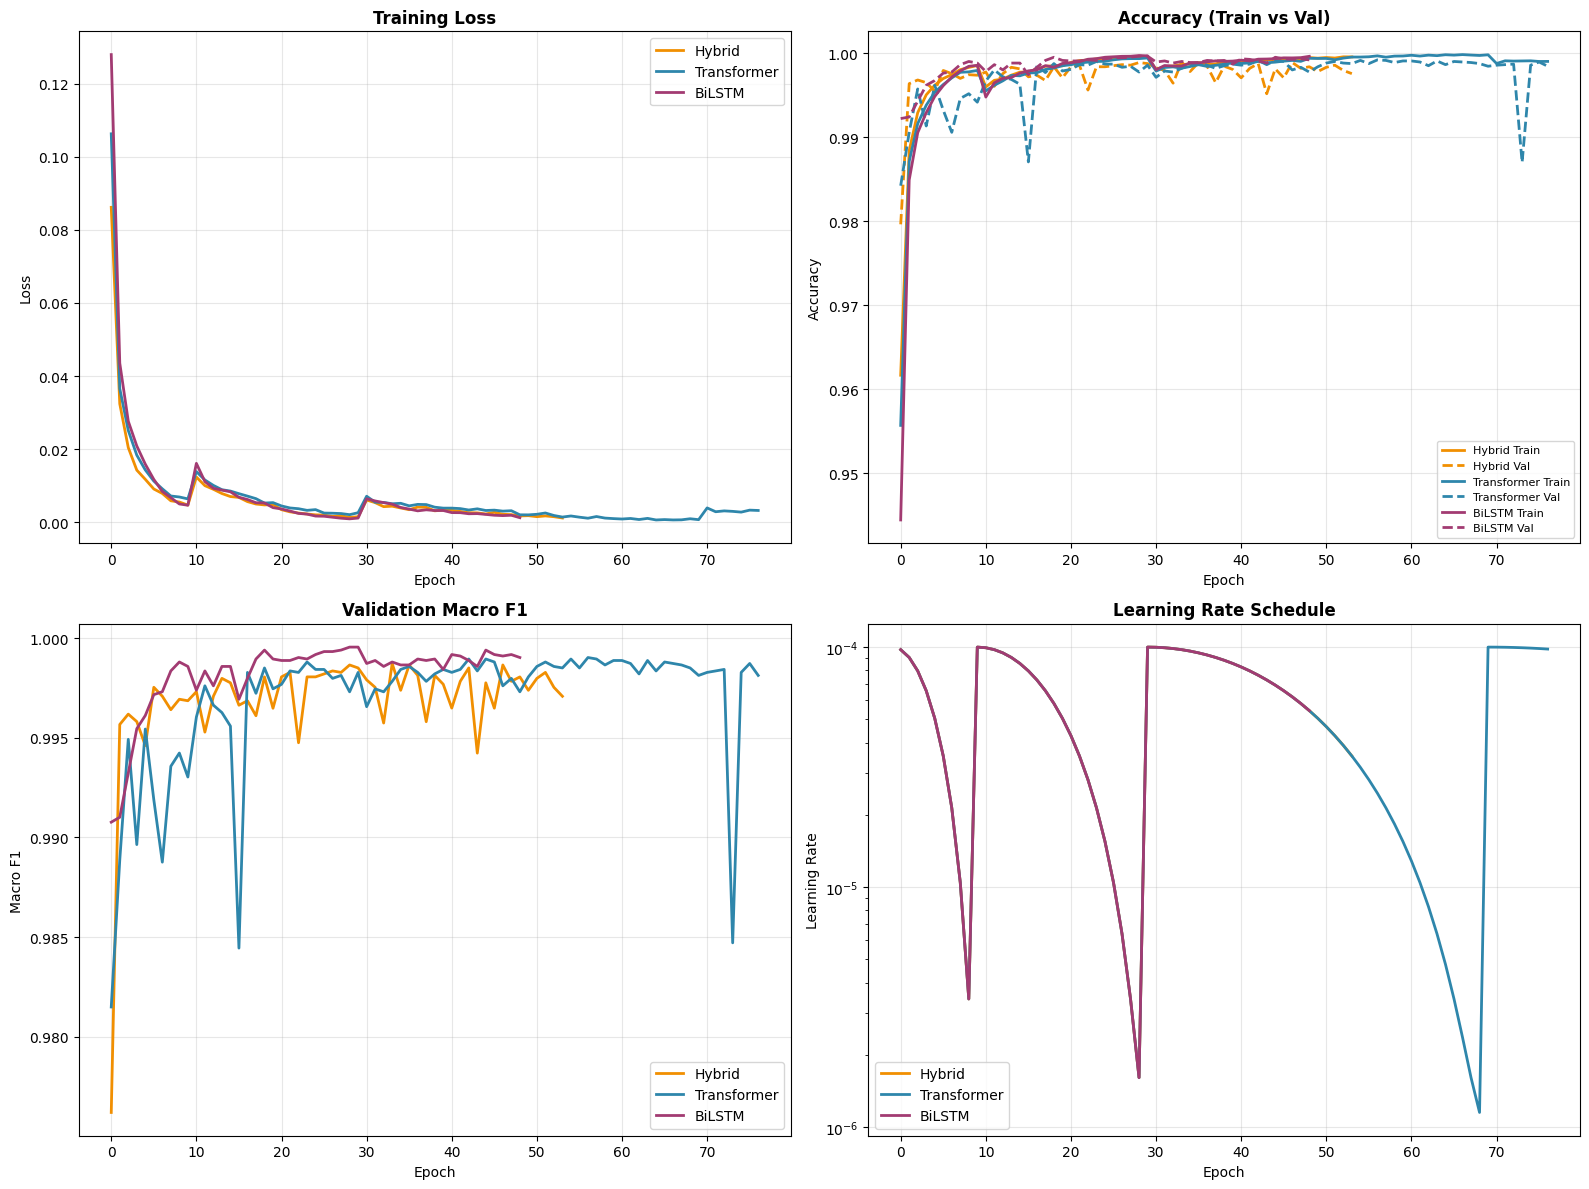

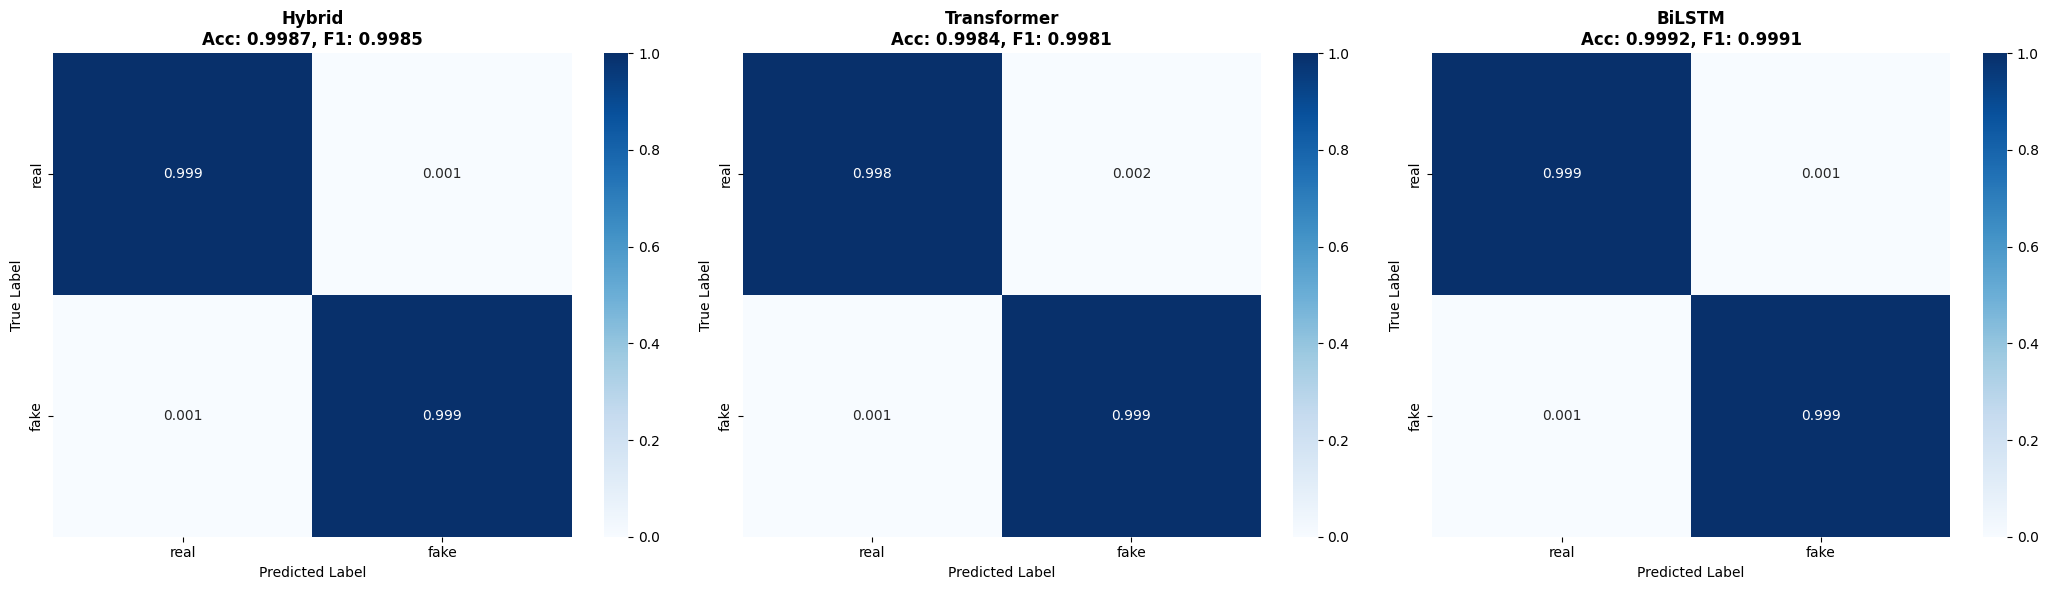

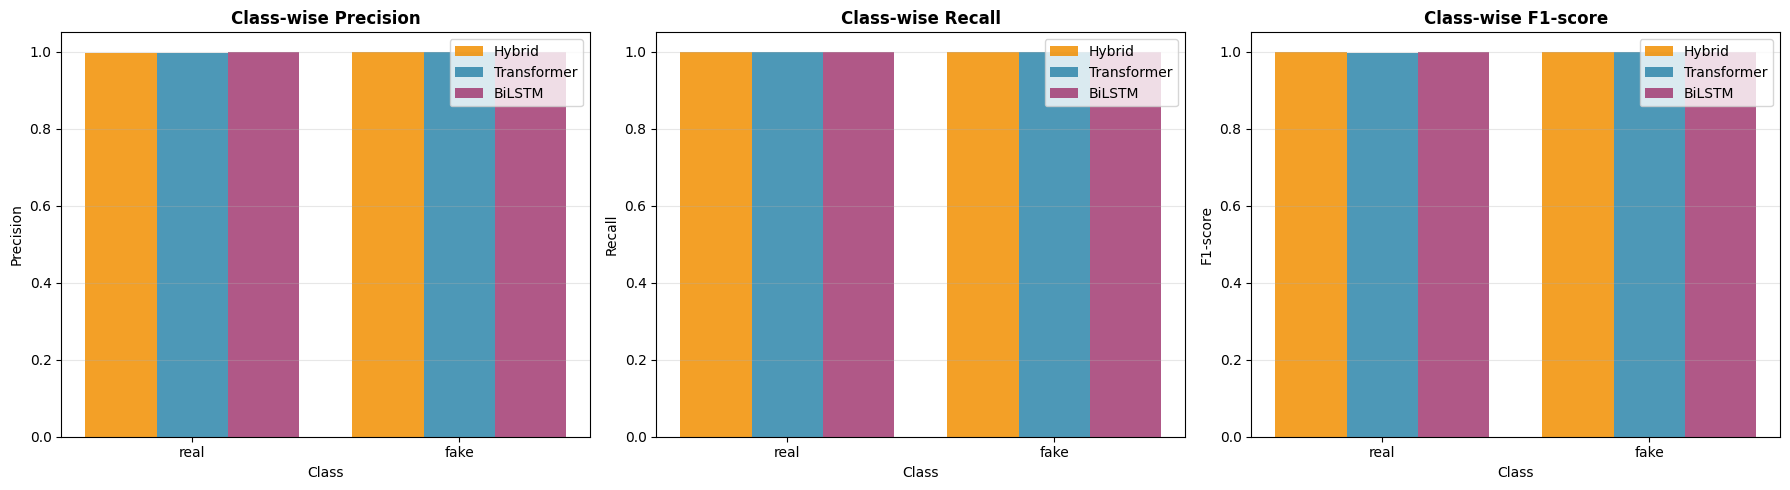

In [10]:
# ==============================================================
# 1. 학습 곡선 비교
# ==============================================================

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
colors = {'Transformer': '#2E86AB', 'BiLSTM': '#A23B72', 'Hybrid': '#F18F01'}

for name, hist in all_histories.items():
    axes[0, 0].plot(hist['train_loss'], label=name,
                     color=colors.get(name, 'gray'), linewidth=2)
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].set_title('Training Loss', fontweight='bold')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

for name, hist in all_histories.items():
    c = colors.get(name, 'gray')
    axes[0, 1].plot(hist['train_acc'], label=f'{name} Train',
                     color=c, linewidth=2, linestyle='-')
    axes[0, 1].plot(hist['val_acc'], label=f'{name} Val',
                     color=c, linewidth=2, linestyle='--')
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Accuracy')
axes[0, 1].set_title('Accuracy (Train vs Val)', fontweight='bold')
axes[0, 1].legend(fontsize=8)
axes[0, 1].grid(True, alpha=0.3)

for name, hist in all_histories.items():
    axes[1, 0].plot(hist['val_f1'], label=name,
                     color=colors.get(name, 'gray'), linewidth=2)
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('Macro F1')
axes[1, 0].set_title('Validation Macro F1', fontweight='bold')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

for name, hist in all_histories.items():
    axes[1, 1].plot(hist['lr'], label=name,
                     color=colors.get(name, 'gray'), linewidth=2)
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('Learning Rate')
axes[1, 1].set_title('Learning Rate Schedule', fontweight='bold')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)
axes[1, 1].set_yscale('log')

plt.tight_layout()
plt.savefig('training_curves_2stage.png', dpi=150, bbox_inches='tight')
plt.show()

# ==============================================================
# 2. 모델별 혼동 행렬
# ==============================================================

n_models = len(all_results)
fig, axes = plt.subplots(1, n_models, figsize=(7 * n_models, 6))
if n_models == 1:
    axes = [axes]

for idx, (name, result) in enumerate(all_results.items()):
    cm = result['cm']
    cm_norm = cm.astype('float') / cm.sum(axis=1, keepdims=True)
    sns.heatmap(cm_norm, annot=True, fmt='.3f', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names,
                ax=axes[idx], vmin=0, vmax=1)
    axes[idx].set_title(
        f'{name}\nAcc: {result["accuracy"]:.4f}, F1: {result["macro_f1"]:.4f}',
        fontweight='bold')
    axes[idx].set_ylabel('True Label')
    axes[idx].set_xlabel('Predicted Label')

plt.tight_layout()
plt.savefig('confusion_matrices_2stage.png', dpi=150, bbox_inches='tight')
plt.show()

# ==============================================================
# 3. 클래스별 성능 비교 바 차트
# ==============================================================

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
metrics = ['precision', 'recall', 'f1-score']

for midx, metric in enumerate(metrics):
    model_names_list = list(all_results.keys())
    x = np.arange(len(class_names))
    width = 0.8 / len(model_names_list)

    for i, name in enumerate(model_names_list):
        report_dict = classification_report(
            all_results[name]['labels'], all_results[name]['preds'],
            target_names=class_names, output_dict=True
        )
        values = [report_dict[cn][metric] for cn in class_names]
        axes[midx].bar(x + i * width, values, width, label=name,
                       color=colors.get(name, 'gray'), alpha=0.85)

    axes[midx].set_xlabel('Class')
    axes[midx].set_ylabel(metric.capitalize())
    axes[midx].set_title(f'Class-wise {metric.capitalize()}', fontweight='bold')
    axes[midx].set_xticks(x + width * (len(model_names_list) - 1) / 2)
    axes[midx].set_xticklabels(class_names)
    axes[midx].legend()
    axes[midx].set_ylim(0, 1.05)
    axes[midx].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('classwise_performance_2stage.png', dpi=150, bbox_inches='tight')
plt.show()


---
## 셀 10: 최종 성능 요약

In [11]:
# ==============================================================
# 최종 성능 요약
# ==============================================================

print("=" * 70)
print("2-Stage 딥페이크 음성 탐지 - 최종 성능 요약")
print("=" * 70)

print(f"\n{'모델':<25} {'테스트 정확도':>15} {'Macro F1':>12}")
print("-" * 55)
for name, result in all_results.items():
    print(f"  {name:<23} {result['accuracy']:>15.4f} {result['macro_f1']:>12.4f}")

print("-" * 55)
print(f"\n클래스별 Recall 비교:")
print(f"{'모델':<25}", end="")
for cn in class_names:
    print(f" {cn:>10}", end="")
print()
print("-" * 55)

for name, result in all_results.items():
    report_dict = classification_report(
        result['labels'], result['preds'],
        target_names=class_names, output_dict=True
    )
    print(f"  {name:<23}", end="")
    for cn in class_names:
        print(f" {report_dict[cn]['recall']:>10.4f}", end="")
    print()

best_model_name = max(all_results, key=lambda k: all_results[k]['macro_f1'])
print(f"\n최고 모델: {best_model_name} "
      f"(Macro F1: {all_results[best_model_name]['macro_f1']:.4f})")

print(f"\n저장된 산출물:")
print(f"  seq_scaler_2stage.pkl")
for name in MODELS_TO_TRAIN:
    fname = f'best_2stage_{name.lower()}.pt'
    if os.path.exists(fname):
        size_mb = os.path.getsize(fname) / (1024 * 1024)
        print(f"  {fname:<35} ({size_mb:.1f} MB)")

if torch.cuda.is_available():
    print(f"\nGPU 메모리: "
          f"할당 {torch.cuda.memory_allocated(0)/1024**3:.2f} GB, "
          f"캐시 {torch.cuda.memory_reserved(0)/1024**3:.2f} GB")

print("\n" + "=" * 70)
print("완료!")
print("=" * 70)


2-Stage 딥페이크 음성 탐지 - 최종 성능 요약

모델                                테스트 정확도     Macro F1
-------------------------------------------------------
  Hybrid                           0.9987       0.9985
  Transformer                      0.9984       0.9981
  BiLSTM                           0.9992       0.9991
-------------------------------------------------------

클래스별 Recall 비교:
모델                              real       fake
-------------------------------------------------------
  Hybrid                      0.9987     0.9987
  Transformer                 0.9979     0.9986
  BiLSTM                      0.9994     0.9992

최고 모델: BiLSTM (Macro F1: 0.9991)

저장된 산출물:
  seq_scaler_2stage.pkl
  best_2stage_hybrid.pt               (12.2 MB)
  best_2stage_transformer.pt          (13.3 MB)
  best_2stage_bilstm.pt               (17.0 MB)

GPU 메모리: 할당 0.12 GB, 캐시 9.41 GB

완료!


---
## 셀 11: 추론 파이프라인

학습된 2-Stage 모델로 새 오디오 파일 예측:
1. 오디오 로드 -> 다중 음향 특징 (106D/frame)
2. (선택) Stage 1 임베딩 (256D/frame)
3. 특징 결합 + 정규화
4. Stage 2 시퀀스 모델 분류
5. 예측 결과 및 신뢰도 출력


In [12]:
def load_2stage_pipeline(stage2_model_class, stage2_path,
                         stage1_path='best_asvspoof_model.pt',
                         scaler_path='seq_scaler_2stage.pkl',
                         mfcc_scaler_path='scaler_asvspoof.pkl',
                         input_dim=None, device=None):
    # 2-Stage 추론 파이프라인 로드
    #
    # 흐름: 오디오 -> 다중특징(106D) + Stage1임베딩(256D) -> 정규화
    #       -> Stage2 시퀀스모델 -> 예측
    if device is None:
        device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    pipeline = {'device': device}

    # Stage 1 (선택적)
    if os.path.exists(stage1_path):
        pipeline['stage1'] = Stage1EmbeddingExtractor.from_pretrained(
            stage1_path, input_dim=N_MFCC, device=device
        )
        pipeline['stage1'].eval()
    else:
        pipeline['stage1'] = None

    # MFCC 스케일러
    if os.path.exists(mfcc_scaler_path):
        pipeline['mfcc_scaler'] = joblib.load(mfcc_scaler_path)
    else:
        pipeline['mfcc_scaler'] = None

    # 시퀀스 스케일러
    pipeline['seq_scaler'] = joblib.load(scaler_path)

    # Stage 2 모델
    if input_dim is None:
        input_dim = FEAT_DIM
    stage2 = stage2_model_class(input_dim=input_dim, num_classes=NUM_CLASSES)
    stage2.load_state_dict(torch.load(stage2_path, map_location=device))
    stage2 = stage2.to(device)
    stage2.eval()
    pipeline['stage2'] = stage2

    return pipeline


def predict_audio(audio_path, pipeline):
    # 새로운 오디오 파일에 대해 2-Stage 예측 수행
    #
    # 반환: 예측 클래스, 신뢰도, 클래스별 확률
    device = pipeline['device']

    # 1. 다중 음향 특징
    multi_feat = extract_multi_features_per_frame(audio_path)
    if multi_feat is None:
        return {'error': 'feature extraction failed'}

    # 2. Stage 1 임베딩 (선택적)
    if pipeline['stage1'] is not None:
        y, _ = librosa.load(audio_path, sr=SAMPLE_RATE)
        mfcc_raw = librosa.feature.mfcc(
            y=y, sr=SAMPLE_RATE, n_mfcc=N_MFCC,
            n_fft=N_FFT, hop_length=HOP_LENGTH, win_length=WIN_LENGTH
        ).T

        T = min(multi_feat.shape[0], mfcc_raw.shape[0])
        multi_feat = multi_feat[:T]
        mfcc_raw = mfcc_raw[:T]

        if pipeline['mfcc_scaler'] is not None:
            mfcc_raw = pipeline['mfcc_scaler'].transform(mfcc_raw)

        with torch.no_grad():
            mfcc_tensor = torch.FloatTensor(mfcc_raw).unsqueeze(0).to(device)
            embedding = pipeline['stage1'](mfcc_tensor).squeeze(0).cpu().numpy()

        combined = np.concatenate([multi_feat, embedding[:T]], axis=1)
    else:
        combined = multi_feat

    # 3. 정규화
    combined = pipeline['seq_scaler'].transform(combined)

    # 4. Stage 2 예측
    with torch.no_grad():
        seq_tensor = torch.FloatTensor(combined).unsqueeze(0).to(device)
        lengths = torch.LongTensor([combined.shape[0]]).to(device)
        outputs = pipeline['stage2'](seq_tensor, lengths)
        probs = F.softmax(outputs, dim=1).cpu().numpy()[0]
        pred_class = np.argmax(probs)

    return {
        'file': os.path.basename(audio_path),
        'prediction': class_names[pred_class],
        'confidence': float(probs[pred_class]),
        'probabilities': {
            class_names[i]: float(probs[i]) for i in range(len(class_names))
        },
        'num_frames': combined.shape[0],
        'feature_dim': combined.shape[1]
    }


# 추론 테스트
print("2-Stage 추론 파이프라인 테스트")
print("-" * 50)

best_model_class = {
    'Transformer': TransformerClassifier,
    'BiLSTM': BiLSTMClassifier,
    'Hybrid': HybridTransformerLSTM
}[best_model_name]

best_model_path = f'best_2stage_{best_model_name.lower()}.pt'

if os.path.exists(best_model_path):
    pipeline = load_2stage_pipeline(
        best_model_class, best_model_path, input_dim=FEAT_DIM
    )
    print(f"파이프라인 로드 완료 (Stage 2: {best_model_name})")
    print(f"  Stage 1: {'사용' if pipeline['stage1'] is not None else '미사용'}")
    print(f"  입력 차원: {FEAT_DIM}")

    test_dir = os.path.join(BASE_DIR, 'test')
    if os.path.exists(test_dir):
        print("\n샘플 추론:")
        for cls_name in class_names:
            cls_dir = os.path.join(test_dir, cls_name)
            if os.path.exists(cls_dir):
                files = sorted(glob(os.path.join(cls_dir, '*.wav')))[:2]
                for f in files:
                    result = predict_audio(f, pipeline)
                    if 'error' not in result:
                        print(f"  [{cls_name:6s}] {result['file']:30s} -> "
                              f"{result['prediction']:6s} "
                              f"(conf: {result['confidence']:.4f})")
else:
    print(f"모델 파일 '{best_model_path}' 없음")

print("\n모든 작업 완료!")


2-Stage 추론 파이프라인 테스트
--------------------------------------------------
파이프라인 로드 완료 (Stage 2: BiLSTM)
  Stage 1: 미사용
  입력 차원: 106

샘플 추론:
  [real  ] R_000000.wav                   -> fake   (conf: 0.9976)
  [real  ] R_000001.wav                   -> fake   (conf: 0.9988)
  [fake  ] F_000000.wav                   -> fake   (conf: 0.9981)
  [fake  ] F_000001.wav                   -> fake   (conf: 0.9973)

모든 작업 완료!


---
## 셀 12: 아키텍처 요약

```
                    2-Stage 딥페이크 음성 탐지 시스템
                    ================================

 [오디오 입력 (WAV)]
        |
        v
 +----------------------------------------------+
 |     다중 음향 특징 추출 (프레임 단위)           |
 |  MFCC (13D) + Delta (13D) + Delta2 (13D)     |
 |  LFCC (20D) + Mel-Spec (40D) + Contrast (7D) |
 |  합계: 106차원 프레임 벡터                      |
 +----------------------------------------------+
        |                    |
        |                    v
        |     +--------------------------------------+
        |     | Stage 1: SE-Attention 임베딩 추출기   |
        |     | (기존 모델 전이 학습)                  |
        |     | MFCC(13) -> FC+SE -> 256D 임베딩      |
        |     +--------------------------------------+
        |                    |
        v                    v
 +----------------------------------------------+
 |  프레임 특징 결합: 106D + 256D = 362D          |
 +----------------------------------------------+
        |
        v
 +----------------------------------------------+
 |     Stage 2: 시간적 시퀀스 모델링               |
 |  A. Transformer Encoder (글로벌 어텐션)        |
 |  B. BiLSTM (양방향 순차 모델링)                |
 |  C. Hybrid (Transformer + BiLSTM)             |
 +----------------------------------------------+
        |
        v
 +----------------------------------------------+
 |  Attention Pooling -> Classification Head     |
 |  -> 3클래스 (Real / Fake / TTS)               |
 +----------------------------------------------+
```

### 기존 1-Stage와의 핵심 차이점

| 항목 | 1-Stage (기존) | 2-Stage (제안) |
|------|---------------|---------------|
| 입력 | MFCC 13D 평균 벡터 (1D) | 106D 다중특징 시퀀스 (2D) |
| 시간 정보 | 소실 (mean pooling) | 보존 (프레임 시퀀스) |
| 특징 종류 | MFCC만 | MFCC+LFCC+Mel+Contrast+Delta |
| 모델 | FC + SE 어텐션 | Transformer / BiLSTM / Hybrid |
| 전이 학습 | 없음 | Stage 1 임베딩 재활용 |
| 데이터 증강 | SMOTE (벡터 보간) | SpecAugment (시간/특징 마스킹) |


## 시각화 - 논문용 그림 일괄 생성

각 셀은 독립적으로 실행 가능하며, 한 셀이 실패해도 다음 셀은 계속 진행됩니다.

In [13]:
# ==============================================================
# 시각화 모음 - 논문용 그림 일괄 생성
#
# 안전성 설계:
#   - matplotlib backend를 'Agg'로 고정 (GUI 없이 PNG 저장)
#   - 청크 단위 샘플링으로 RAM 사용량 제어
#   - 각 그림은 독립 try/except 블록으로 묶어 한 그림이 실패해도 나머지 진행
#   - 모든 산출물은 figures/ 폴더에 PNG로 저장
# ==============================================================

import os
import gc
import pickle
import warnings
import numpy as np
import matplotlib
matplotlib.use('Agg')   # GUI 비활성, 메모리 누수 방지
import matplotlib.pyplot as plt
from matplotlib import cm
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401
import seaborn as sns
import librosa
import librosa.display

warnings.filterwarnings('ignore')

FIG_DIR = 'figures'
os.makedirs(FIG_DIR, exist_ok=True)

# matplotlib 전역 설정 - 논문용
plt.rcParams.update({
    'figure.dpi': 150,
    'savefig.dpi': 300,           # 출판용 고해상도
    'savefig.bbox': 'tight',
    'savefig.facecolor': 'white',
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'legend.fontsize': 10,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'figure.autolayout': True,
})

CLASS_NAMES = ['real', 'fake']
CLASS_COLORS = {'real': '#2E86AB', 'fake': '#E63946'}

print(f"시각화 출력 디렉터리: {FIG_DIR}/")
print(f"backend: {matplotlib.get_backend()}")


def safe_save(fig, name, dpi=300):
    # 그림 저장 + 메모리 즉시 해제
    path = os.path.join(FIG_DIR, name)
    fig.savefig(path, dpi=dpi, bbox_inches='tight', facecolor='white')
    plt.close(fig)
    gc.collect()
    print(f"  saved: {path}")


시각화 출력 디렉터리: figures/
backend: Agg


In [14]:
# ==============================================================
# Figure 1: 데이터셋 클래스 분포 (split별 막대 그래프)
# ==============================================================

try:
    splits = ['train', 'val', 'test']
    counts = {s: {c: 0 for c in CLASS_NAMES} for s in splits}
    for s in splits:
        labels = data_sequences[s]['labels']
        for l in labels:
            counts[s][CLASS_NAMES[l]] += 1

    fig, ax = plt.subplots(figsize=(8, 5))
    x = np.arange(len(splits))
    width = 0.35
    real_counts = [counts[s]['real'] for s in splits]
    fake_counts = [counts[s]['fake'] for s in splits]

    b1 = ax.bar(x - width/2, real_counts, width, label='real',
                color=CLASS_COLORS['real'], edgecolor='black', linewidth=0.5)
    b2 = ax.bar(x + width/2, fake_counts, width, label='fake',
                color=CLASS_COLORS['fake'], edgecolor='black', linewidth=0.5)

    for bars in (b1, b2):
        for bar in bars:
            h = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2, h, f'{int(h):,}',
                    ha='center', va='bottom', fontsize=9)

    ax.set_xticks(x)
    ax.set_xticklabels([s.capitalize() for s in splits])
    ax.set_ylabel('Number of samples')
    ax.set_title('Dataset class distribution by split')
    ax.legend(frameon=True)
    ax.grid(axis='y', alpha=0.3)
    safe_save(fig, '01_dataset_distribution.png')
except Exception as e:
    print(f"  [SKIP] dataset distribution: {e}")


# ==============================================================
# Figure 2: 시퀀스 길이 분포 (히스토그램)
# ==============================================================

try:
    fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
    for ax, split in zip(axes, ['train', 'val', 'test']):
        lengths = np.array(data_sequences[split]['lengths'])
        labels = np.array(data_sequences[split]['labels'])
        for cls_idx, cls_name in enumerate(CLASS_NAMES):
            mask = labels == cls_idx
            ax.hist(lengths[mask], bins=40, alpha=0.6, label=cls_name,
                    color=CLASS_COLORS[cls_name], edgecolor='black', linewidth=0.3)
        ax.set_title(f'{split.capitalize()} (n={len(lengths):,})')
        ax.set_xlabel('Sequence length (frames)')
        ax.legend()
        ax.grid(alpha=0.3)
    axes[0].set_ylabel('Count')
    fig.suptitle('Sequence length distribution per split', y=1.02)
    safe_save(fig, '02_sequence_length_distribution.png')
except Exception as e:
    print(f"  [SKIP] sequence length distribution: {e}")


  saved: figures\01_dataset_distribution.png
  saved: figures\02_sequence_length_distribution.png


In [15]:
# ==============================================================
# Figure 3: 단일 샘플 비교 (real vs fake)
#   waveform / mel-spectrogram / MFCC / LFCC / spectral contrast
# ==============================================================

import random
from glob import glob as _glob

try:
    # 클래스별 샘플 1개씩 선택
    samples = {}
    for cls_name in CLASS_NAMES:
        folder = os.path.join(BASE_DIR, 'train', cls_name)
        files = sorted(_glob(os.path.join(folder, '*.wav')))
        if files:
            random.seed(42)
            samples[cls_name] = random.choice(files[:500])  # 앞 500개에서 랜덤

    fig, axes = plt.subplots(5, 2, figsize=(14, 16))

    for col, cls_name in enumerate(CLASS_NAMES):
        if cls_name not in samples:
            continue
        path = samples[cls_name]
        y_audio, _ = librosa.load(path, sr=SAMPLE_RATE,
                                  duration=SEGMENT_LENGTH + 0.5)

        # Row 0: waveform
        ax = axes[0, col]
        t = np.arange(len(y_audio)) / SAMPLE_RATE
        ax.plot(t, y_audio, color=CLASS_COLORS[cls_name], linewidth=0.4)
        ax.set_title(f'{cls_name.upper()} - Waveform\n{os.path.basename(path)}')
        ax.set_xlabel('Time (s)')
        ax.set_ylabel('Amplitude')
        ax.grid(alpha=0.3)

        # Row 1: mel-spectrogram
        ax = axes[1, col]
        S = librosa.feature.melspectrogram(
            y=y_audio, sr=SAMPLE_RATE, n_mels=N_MELS,
            n_fft=N_FFT, hop_length=HOP_LENGTH, win_length=WIN_LENGTH
        )
        S_db = librosa.power_to_db(S, ref=np.max)
        img = librosa.display.specshow(
            S_db, sr=SAMPLE_RATE, hop_length=HOP_LENGTH,
            x_axis='time', y_axis='mel', ax=ax, cmap='magma'
        )
        ax.set_title(f'{cls_name.upper()} - Mel-spectrogram')
        fig.colorbar(img, ax=ax, format='%+2.0f dB')

        # Row 2: MFCC
        ax = axes[2, col]
        mfcc = librosa.feature.mfcc(
            y=y_audio, sr=SAMPLE_RATE, n_mfcc=N_MFCC,
            n_fft=N_FFT, hop_length=HOP_LENGTH, win_length=WIN_LENGTH
        )
        img = librosa.display.specshow(
            mfcc, sr=SAMPLE_RATE, hop_length=HOP_LENGTH,
            x_axis='time', ax=ax, cmap='viridis'
        )
        ax.set_title(f'{cls_name.upper()} - MFCC ({N_MFCC} coeffs)')
        ax.set_ylabel('MFCC index')
        fig.colorbar(img, ax=ax)

        # Row 3: LFCC
        ax = axes[3, col]
        lfcc = compute_lfcc(y_audio, SAMPLE_RATE)
        img = librosa.display.specshow(
            lfcc, sr=SAMPLE_RATE, hop_length=HOP_LENGTH,
            x_axis='time', ax=ax, cmap='cividis'
        )
        ax.set_title(f'{cls_name.upper()} - LFCC ({N_LFCC} coeffs)')
        ax.set_ylabel('LFCC index')
        fig.colorbar(img, ax=ax)

        # Row 4: spectral contrast
        ax = axes[4, col]
        sc = librosa.feature.spectral_contrast(
            y=y_audio, sr=SAMPLE_RATE, n_fft=N_FFT,
            hop_length=HOP_LENGTH, n_bands=6
        )
        img = librosa.display.specshow(
            sc, sr=SAMPLE_RATE, hop_length=HOP_LENGTH,
            x_axis='time', ax=ax, cmap='coolwarm'
        )
        ax.set_title(f'{cls_name.upper()} - Spectral contrast (7 bands)')
        ax.set_ylabel('Sub-band')
        fig.colorbar(img, ax=ax)

    fig.suptitle('Per-sample feature comparison: real vs fake', y=1.005, fontsize=14)
    safe_save(fig, '03_single_sample_features.png')
except Exception as e:
    print(f"  [SKIP] single sample features: {e}")


  saved: figures\03_single_sample_features.png


In [16]:
# ==============================================================
# Figure 4: 클래스별 특징 평균/분산 비교 (전체 데이터 통계)
#
# 메모리 안전: data_sequences는 이미 정규화된 시퀀스를 들고 있으므로
# 전체 평균 대신 청크 단위로 누적
# ==============================================================

try:
    FEAT_NAMES = (
        ['MFCC_'+str(i) for i in range(13)] +
        ['MFCCd_'+str(i) for i in range(13)] +
        ['MFCCdd_'+str(i) for i in range(13)] +
        ['LFCC_'+str(i) for i in range(20)] +
        ['Mel_'+str(i) for i in range(40)] +
        ['SC_'+str(i) for i in range(7)]
    )
    feat_dim = data_sequences['train']['sequences'][0].shape[1]
    if len(FEAT_NAMES) != feat_dim:
        FEAT_NAMES = [f'f{i}' for i in range(feat_dim)]

    # 클래스별 mean/std 누적
    sums = {0: np.zeros(feat_dim, dtype=np.float64),
            1: np.zeros(feat_dim, dtype=np.float64)}
    sumsq = {0: np.zeros(feat_dim, dtype=np.float64),
             1: np.zeros(feat_dim, dtype=np.float64)}
    counts = {0: 0, 1: 0}

    seqs = data_sequences['train']['sequences']
    labels = data_sequences['train']['labels']
    BATCH = 500
    for i in range(0, len(seqs), BATCH):
        batch_seqs = seqs[i:i+BATCH]
        batch_labels = labels[i:i+BATCH]
        for s, l in zip(batch_seqs, batch_labels):
            arr = s.astype(np.float64)
            sums[l] += arr.sum(axis=0)
            sumsq[l] += (arr ** 2).sum(axis=0)
            counts[l] += arr.shape[0]
        gc.collect()

    means = {}
    stds = {}
    for c in [0, 1]:
        n = counts[c]
        means[c] = sums[c] / n
        var = sumsq[c] / n - means[c] ** 2
        stds[c] = np.sqrt(np.clip(var, 0, None))

    # 평균 비교 막대그래프 (특징 인덱스 가로축)
    fig, axes = plt.subplots(2, 1, figsize=(16, 8))

    x = np.arange(feat_dim)
    axes[0].plot(x, means[0], color=CLASS_COLORS['real'],
                 label='real', linewidth=1.5, alpha=0.85)
    axes[0].plot(x, means[1], color=CLASS_COLORS['fake'],
                 label='fake', linewidth=1.5, alpha=0.85)
    axes[0].fill_between(x, means[0]-stds[0], means[0]+stds[0],
                         color=CLASS_COLORS['real'], alpha=0.15)
    axes[0].fill_between(x, means[1]-stds[1], means[1]+stds[1],
                         color=CLASS_COLORS['fake'], alpha=0.15)
    axes[0].axvline(13, color='gray', linestyle='--', alpha=0.5)
    axes[0].axvline(26, color='gray', linestyle='--', alpha=0.5)
    axes[0].axvline(39, color='gray', linestyle='--', alpha=0.5)
    axes[0].axvline(59, color='gray', linestyle='--', alpha=0.5)
    axes[0].axvline(99, color='gray', linestyle='--', alpha=0.5)
    axes[0].set_xlabel('Feature index')
    axes[0].set_ylabel('Mean (normalized)')
    axes[0].set_title('Per-feature class mean +/- std (train set)')
    axes[0].legend()
    axes[0].grid(alpha=0.3)

    # 평균 차이 (fake - real)
    diff = means[1] - means[0]
    colors = ['#E63946' if d > 0 else '#2E86AB' for d in diff]
    axes[1].bar(x, diff, color=colors, edgecolor='black', linewidth=0.3)
    axes[1].axvline(13, color='gray', linestyle='--', alpha=0.5)
    axes[1].axvline(26, color='gray', linestyle='--', alpha=0.5)
    axes[1].axvline(39, color='gray', linestyle='--', alpha=0.5)
    axes[1].axvline(59, color='gray', linestyle='--', alpha=0.5)
    axes[1].axvline(99, color='gray', linestyle='--', alpha=0.5)
    axes[1].set_xlabel('Feature index')
    axes[1].set_ylabel('Mean difference (fake - real)')
    axes[1].set_title('Class-wise mean difference per feature dimension')
    axes[1].grid(alpha=0.3)

    # 그룹 라벨 (MFCC, MFCCd, MFCCdd, LFCC, Mel, SC)
    group_labels = [(0,13,'MFCC'), (13,26,'MFCC-d'), (26,39,'MFCC-dd'),
                    (39,59,'LFCC'), (59,99,'Mel'), (99,106,'SC')]
    for ax in axes:
        for s, e, name in group_labels:
            ax.text((s+e)/2, ax.get_ylim()[1]*0.95, name,
                    ha='center', fontsize=9, color='gray')

    safe_save(fig, '04_class_feature_statistics.png')
    del sums, sumsq
    gc.collect()
except Exception as e:
    print(f"  [SKIP] class feature statistics: {e}")


  saved: figures\04_class_feature_statistics.png


In [17]:
# ==============================================================
# Figure 5: 시퀀스 임베딩 시각화 (PCA 2D, PCA 3D, t-SNE 2D)
#
# 메모리 안전: 시퀀스를 평균 풀링하여 (N, 106) 행렬로 압축
# 샘플링: train에서 클래스별 최대 N_SAMPLE_PER_CLASS개만 사용
# ==============================================================

from sklearn.decomposition import PCA

try:
    N_SAMPLE_PER_CLASS = 3000   # 너무 크면 t-SNE가 매우 느려짐

    # 평균 풀링 임베딩 추출
    def get_pooled_embeddings(split='train', n_per_class=N_SAMPLE_PER_CLASS):
        seqs = data_sequences[split]['sequences']
        labels = np.array(data_sequences[split]['labels'])
        idx_real = np.where(labels == 0)[0]
        idx_fake = np.where(labels == 1)[0]
        rng = np.random.RandomState(42)
        if len(idx_real) > n_per_class:
            idx_real = rng.choice(idx_real, n_per_class, replace=False)
        if len(idx_fake) > n_per_class:
            idx_fake = rng.choice(idx_fake, n_per_class, replace=False)
        sel = np.concatenate([idx_real, idx_fake])
        rng.shuffle(sel)

        feat_dim = seqs[0].shape[1]
        X = np.zeros((len(sel), feat_dim), dtype=np.float32)
        y = np.zeros(len(sel), dtype=np.int64)
        for i, idx in enumerate(sel):
            X[i] = seqs[idx].mean(axis=0)
            y[i] = labels[idx]
        return X, y

    print("  임베딩 추출 중...")
    X_emb, y_emb = get_pooled_embeddings('train')
    print(f"  shape: {X_emb.shape}")

    # PCA 2D
    print("  PCA 2D...")
    pca2 = PCA(n_components=2, random_state=42)
    X_pca2 = pca2.fit_transform(X_emb)

    # PCA 3D
    print("  PCA 3D...")
    pca3 = PCA(n_components=3, random_state=42)
    X_pca3 = pca3.fit_transform(X_emb)

    # t-SNE 2D
    try:
        from sklearn.manifold import TSNE
        print("  t-SNE 2D (시간 좀 걸림)...")
        tsne = TSNE(n_components=2, perplexity=30, random_state=42,
                    init='pca', learning_rate='auto', n_iter=1000)
        X_tsne = tsne.fit_transform(X_emb)
        has_tsne = True
    except Exception as e:
        print(f"  t-SNE 실패: {e}")
        has_tsne = False

    # 시각화
    fig = plt.figure(figsize=(18, 6))

    ax1 = fig.add_subplot(1, 3, 1)
    for cls_idx, cls_name in enumerate(CLASS_NAMES):
        mask = y_emb == cls_idx
        ax1.scatter(X_pca2[mask, 0], X_pca2[mask, 1],
                    s=8, alpha=0.5, c=CLASS_COLORS[cls_name], label=cls_name,
                    edgecolors='none')
    ax1.set_title(f'PCA 2D (var: {pca2.explained_variance_ratio_.sum()*100:.1f}%)')
    ax1.set_xlabel(f'PC1 ({pca2.explained_variance_ratio_[0]*100:.1f}%)')
    ax1.set_ylabel(f'PC2 ({pca2.explained_variance_ratio_[1]*100:.1f}%)')
    ax1.legend(markerscale=2)
    ax1.grid(alpha=0.3)

    ax2 = fig.add_subplot(1, 3, 2, projection='3d')
    for cls_idx, cls_name in enumerate(CLASS_NAMES):
        mask = y_emb == cls_idx
        ax2.scatter(X_pca3[mask, 0], X_pca3[mask, 1], X_pca3[mask, 2],
                    s=8, alpha=0.4, c=CLASS_COLORS[cls_name], label=cls_name,
                    edgecolors='none')
    ax2.set_title(f'PCA 3D (var: {pca3.explained_variance_ratio_.sum()*100:.1f}%)')
    ax2.set_xlabel(f'PC1')
    ax2.set_ylabel(f'PC2')
    ax2.set_zlabel(f'PC3')
    ax2.legend(markerscale=2)

    ax3 = fig.add_subplot(1, 3, 3)
    if has_tsne:
        for cls_idx, cls_name in enumerate(CLASS_NAMES):
            mask = y_emb == cls_idx
            ax3.scatter(X_tsne[mask, 0], X_tsne[mask, 1],
                        s=8, alpha=0.5, c=CLASS_COLORS[cls_name], label=cls_name,
                        edgecolors='none')
        ax3.set_title('t-SNE 2D (perplexity=30)')
        ax3.set_xlabel('t-SNE 1')
        ax3.set_ylabel('t-SNE 2')
        ax3.legend(markerscale=2)
    else:
        ax3.text(0.5, 0.5, 't-SNE skipped',
                 ha='center', va='center', transform=ax3.transAxes)
    ax3.grid(alpha=0.3)

    fig.suptitle(f'Sequence-mean embeddings ({len(X_emb):,} samples)', y=1.02)
    safe_save(fig, '05_embedding_projections.png')
    del X_emb, X_pca2, X_pca3
    if has_tsne:
        del X_tsne
    gc.collect()
except Exception as e:
    print(f"  [SKIP] embedding projections: {e}")


  임베딩 추출 중...
  shape: (6000, 106)
  PCA 2D...
  PCA 3D...
  t-SNE 2D (시간 좀 걸림)...
  t-SNE 실패: TSNE.__init__() got an unexpected keyword argument 'n_iter'
  saved: figures\05_embedding_projections.png


In [18]:
# ==============================================================
# Figure 6: 학습 곡선 (모든 모델 비교)
# Figure 7: confusion matrix (모델별)
# Figure 8: ROC + PR curve (모델별)
#
# 전제: all_histories, all_best_accs, models 가 정의되어 있어야 함
# ==============================================================

from sklearn.metrics import (
    confusion_matrix, classification_report,
    roc_curve, auc, precision_recall_curve, average_precision_score
)

# --- Figure 6: 학습 곡선 ---
try:
    if 'all_histories' in dir() and all_histories:
        fig, axes = plt.subplots(2, 2, figsize=(14, 9))
        for name, hist in all_histories.items():
            axes[0, 0].plot(hist['train_loss'], label=name, linewidth=2)
            axes[0, 1].plot(hist['train_acc'], label=name, linewidth=2)
            axes[1, 0].plot(hist['val_acc'], label=name, linewidth=2)
            axes[1, 1].plot(hist['val_f1'], label=name, linewidth=2)

        axes[0, 0].set_title('Training loss')
        axes[0, 0].set_xlabel('Epoch')
        axes[0, 0].set_ylabel('Loss')
        axes[0, 1].set_title('Training accuracy')
        axes[0, 1].set_xlabel('Epoch')
        axes[0, 1].set_ylabel('Accuracy')
        axes[1, 0].set_title('Validation accuracy')
        axes[1, 0].set_xlabel('Epoch')
        axes[1, 0].set_ylabel('Accuracy')
        axes[1, 1].set_title('Validation macro-F1')
        axes[1, 1].set_xlabel('Epoch')
        axes[1, 1].set_ylabel('Macro-F1')
        for ax in axes.flat:
            ax.legend()
            ax.grid(alpha=0.3)
        fig.suptitle('Training curves across models', y=1.01)
        safe_save(fig, '06_training_curves.png')
    else:
        print("  [SKIP] training curves: all_histories 없음")
except Exception as e:
    print(f"  [SKIP] training curves: {e}")


# --- Figure 7-8: 모델별 confusion matrix + ROC + PR ---
def evaluate_for_viz(model, loader, device):
    # 모델 추론하여 (y_true, y_pred, y_score) 반환
    import torch
    model.eval()
    all_true, all_pred, all_score = [], [], []
    with torch.no_grad():
        for batch_seqs, batch_labels, batch_lengths in loader:
            batch_seqs = batch_seqs.to(device, non_blocking=True)
            batch_lengths = batch_lengths.to(device, non_blocking=True)
            with torch.cuda.amp.autocast(enabled=torch.cuda.is_available()):
                outputs = model(batch_seqs, batch_lengths)
            probs = torch.softmax(outputs.float(), dim=1)
            _, predicted = torch.max(outputs, 1)
            all_true.extend(batch_labels.numpy())
            all_pred.extend(predicted.cpu().numpy())
            all_score.extend(probs[:, 1].cpu().numpy())
    return np.array(all_true), np.array(all_pred), np.array(all_score)


try:
    if 'models' in dir() and 'test_loader' in dir():
        results = {}
        for name in models:
            ckpt = f'best_2stage_{name.lower()}.pt'
            if not os.path.exists(ckpt):
                print(f"  [SKIP] {name}: 체크포인트 없음 ({ckpt})")
                continue
            import torch
            models[name].load_state_dict(torch.load(ckpt, map_location=device))
            models[name].to(device)
            y_true, y_pred, y_score = evaluate_for_viz(models[name], test_loader, device)
            results[name] = (y_true, y_pred, y_score)
            print(f"  {name}: 평가 완료 ({len(y_true):,} samples)")

        # confusion matrices
        if results:
            n = len(results)
            fig, axes = plt.subplots(1, n, figsize=(5*n, 4.5), squeeze=False)
            for i, (name, (yt, yp, _)) in enumerate(results.items()):
                cm_arr = confusion_matrix(yt, yp)
                cm_norm = cm_arr.astype(float) / cm_arr.sum(axis=1, keepdims=True)
                ax = axes[0, i]
                sns.heatmap(cm_norm, annot=True, fmt='.3f', cmap='Blues',
                            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
                            ax=ax, cbar=True, vmin=0, vmax=1, square=True,
                            linewidths=0.5, linecolor='white')
                ax.set_title(f'{name}')
                ax.set_xlabel('Predicted')
                ax.set_ylabel('True')
            fig.suptitle('Confusion matrices (row-normalized)', y=1.04)
            safe_save(fig, '07_confusion_matrices.png')

            # ROC + PR
            fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
            for name, (yt, _, ys) in results.items():
                fpr, tpr, _ = roc_curve(yt, ys)
                roc_auc = auc(fpr, tpr)
                axes[0].plot(fpr, tpr, linewidth=2,
                             label=f'{name} (AUC={roc_auc:.3f})')

                prec, rec, _ = precision_recall_curve(yt, ys)
                ap = average_precision_score(yt, ys)
                axes[1].plot(rec, prec, linewidth=2,
                             label=f'{name} (AP={ap:.3f})')

            axes[0].plot([0, 1], [0, 1], 'k--', alpha=0.4)
            axes[0].set_xlabel('False positive rate')
            axes[0].set_ylabel('True positive rate')
            axes[0].set_title('ROC curve')
            axes[0].legend(loc='lower right')
            axes[0].grid(alpha=0.3)

            axes[1].set_xlabel('Recall')
            axes[1].set_ylabel('Precision')
            axes[1].set_title('Precision-Recall curve')
            axes[1].legend(loc='lower left')
            axes[1].grid(alpha=0.3)

            fig.suptitle('Discrimination curves on test set', y=1.02)
            safe_save(fig, '08_roc_pr_curves.png')

            # 최종 요약 표
            print("\n=== Test set summary ===")
            for name, (yt, yp, ys) in results.items():
                acc = (yt == yp).mean()
                from sklearn.metrics import f1_score, precision_score, recall_score
                f1 = f1_score(yt, yp, average='macro')
                p = precision_score(yt, yp, average='macro')
                r = recall_score(yt, yp, average='macro')
                fpr, tpr, _ = roc_curve(yt, ys)
                roc_auc = auc(fpr, tpr)
                print(f"  {name:12s} | Acc={acc:.4f} | F1={f1:.4f} | "
                      f"P={p:.4f} | R={r:.4f} | AUC={roc_auc:.4f}")
    else:
        print("  [SKIP] evaluation plots: models / test_loader 없음")
except Exception as e:
    print(f"  [SKIP] evaluation plots: {e}")

print("\n시각화 완료. figures/ 폴더 확인.")


  saved: figures\06_training_curves.png
  Transformer: 평가 완료 (15,891 samples)
  BiLSTM: 평가 완료 (15,891 samples)
  Hybrid: 평가 완료 (15,891 samples)
  saved: figures\07_confusion_matrices.png
  saved: figures\08_roc_pr_curves.png

=== Test set summary ===
  Transformer  | Acc=0.9984 | F1=0.9981 | P=0.9979 | R=0.9982 | AUC=0.9997
  BiLSTM       | Acc=0.9992 | F1=0.9991 | P=0.9989 | R=0.9993 | AUC=0.9999
  Hybrid       | Acc=0.9987 | F1=0.9985 | P=0.9983 | R=0.9987 | AUC=0.9999

시각화 완료. figures/ 폴더 확인.


In [19]:
import numpy as np, librosa, librosa.display, matplotlib.pyplot as plt, seaborn as sns, pandas as pd
from glob import glob

SR, N_MFCC, N_FFT, HOP, WIN = 16000, 13, 512, 160, 400

def load_mfcc(path, dur=4.0):
    y,_ = librosa.load(path, sr=SR, duration=dur)
    return librosa.feature.mfcc(y=y, sr=SR, n_mfcc=N_MFCC,
                                n_fft=N_FFT, hop_length=HOP, win_length=WIN)

# --- (1) 단일 샘플 비교 ---
real_path = sorted(glob('DATASET/test/real/*.wav'))[0]
fake_path = sorted(glob('DATASET/test/fake/*.wav'))[0]
m_r, m_f = load_mfcc(real_path), load_mfcc(fake_path)
T = min(m_r.shape[1], m_f.shape[1]); m_r, m_f = m_r[:,:T], m_f[:,:T]
# → 위 Fig A/B 코드 그대로 사용

# --- (2) 다수 샘플 평균 통계 (논문 figure로 강력) ---
def stack_mfcc(folder, n=200, T=300):
    out = []
    for p in sorted(glob(f'{folder}/*.wav'))[:n]:
        m = load_mfcc(p)
        if m.shape[1] >= T:
            out.append(m[:, :T])
    return np.stack(out)  # (N, 13, T)

R = stack_mfcc('DATASET/test/real', n=300)
F = stack_mfcc('DATASET/test/fake', n=300)
# 평균 heatmap, 분산, smoothness를 R.mean(0), F.mean(0) 로 그리면 됨


In [37]:
# 1. F 재정의 확인 및 복구
import torch.nn.functional as F

# 2. measure_inference 그대로 실행
print("=" * 80)
print("모델 복잡도 분석")
print("=" * 80)
print(f"{'Model':<14} {'Params':>12} {'Size(MB)':>10} "
      f"{'Latency(ms)':>14} {'Throughput':>14}")
print("-" * 80)

complexity_results = {}
for name in MODELS_TO_TRAIN:
    model = models[name].to(device)
    n_params = count_parameters(model)
    size_mb  = model_size_mb(model)
    perf     = measure_inference(model, test_loader, device)
    complexity_results[name] = {'params': n_params, 'size_mb': size_mb, **perf}
    print(f"{name:<14} {n_params:>12,} {size_mb:>10.2f} "
          f"{perf['latency_per_batch_ms']:>10.2f}+/-{perf['latency_std_ms']:>4.2f} "
          f"{perf['throughput_samples_per_sec']:>12.0f}/s")

print("=" * 80)

모델 복잡도 분석
Model                Params   Size(MB)    Latency(ms)     Throughput
--------------------------------------------------------------------------------
Hybrid            1,923,587       7.34      41.27+/-5.35         3101/s
Transformer       2,195,011       8.37      19.15+/-0.49         6685/s
BiLSTM            4,466,563      17.04      47.97+/-3.06         2668/s


In [38]:
# ==============================================================
# ROC curve + Precision-Recall curve + EER
#
# anti-spoofing / 음성 위조 탐지 분야 표준 지표:
#   - EER (Equal Error Rate): FAR = FRR이 되는 지점의 오류율
#   - AUC (Area Under ROC Curve)
#   - Average Precision (AP)
# ==============================================================

from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score
from scipy.optimize import brentq
from scipy.interpolate import interp1d

def compute_eer(y_true, y_score):
    # EER 계산 (FAR과 FRR이 같아지는 지점)
    # y_score: positive class(fake) 확률
    fpr, tpr, _ = roc_curve(y_true, y_score)
    fnr = 1 - tpr
    # FPR과 FNR의 교차점
    eer = brentq(lambda x: 1.0 - x - interp1d(fpr, tpr)(x), 0.0, 1.0)
    return eer

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

print("=" * 60)
print("ROC / EER 분석")
print("=" * 60)

eer_results = {}
for name in MODELS_TO_TRAIN:
    res = all_results[name]
    y_true = res['labels']
    y_score = res['probs'][:, 1]   # fake class 확률

    fpr, tpr, _ = roc_curve(y_true, y_score)
    roc_auc = auc(fpr, tpr)
    prec, rec, _ = precision_recall_curve(y_true, y_score)
    ap = average_precision_score(y_true, y_score)
    try:
        eer = compute_eer(y_true, y_score)
    except Exception:
        eer = float('nan')
    eer_results[name] = {'auc': roc_auc, 'ap': ap, 'eer': eer}

    axes[0].plot(fpr, tpr, linewidth=2,
                 label=f'{name} (AUC={roc_auc:.4f}, EER={eer*100:.2f}%)')
    axes[1].plot(rec, prec, linewidth=2,
                 label=f'{name} (AP={ap:.4f})')

    print(f"  {name:12s} | AUC={roc_auc:.4f} | EER={eer*100:.3f}% | AP={ap:.4f}")

axes[0].plot([0, 1], [0, 1], 'k--', alpha=0.4, label='Random')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curve')
axes[0].legend(loc='lower right', fontsize=10)
axes[0].grid(alpha=0.3)

axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curve')
axes[1].legend(loc='lower left', fontsize=10)
axes[1].grid(alpha=0.3)

fig.suptitle('Discrimination performance on test set', y=1.02, fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, '09_roc_pr_eer.png'), dpi=300, bbox_inches='tight')
plt.show()
plt.close(fig)


ROC / EER 분석
  Hybrid       | AUC=0.9999 | EER=0.126% | AP=1.0000
  Transformer  | AUC=0.9997 | EER=0.171% | AP=0.9998
  BiLSTM       | AUC=0.9999 | EER=0.081% | AP=1.0000


In [39]:
# ==============================================================
# Calibration (Reliability Diagram + ECE)
#
# 학술적 가치:
#   - 모델이 출력하는 확률이 실제 정확도와 일치하는지 검증
#   - ECE (Expected Calibration Error): 낮을수록 calibrated
#   - 99% 정확도 모델도 calibration이 안 되어 있으면 신뢰 구간이 깨짐
# ==============================================================

def reliability_diagram(y_true, y_prob, n_bins=10):
    # bin별 실제 accuracy vs 평균 confidence
    bins = np.linspace(0, 1, n_bins + 1)
    bin_acc = []
    bin_conf = []
    bin_count = []
    for i in range(n_bins):
        mask = (y_prob >= bins[i]) & (y_prob < bins[i+1])
        if i == n_bins - 1:
            mask = (y_prob >= bins[i]) & (y_prob <= bins[i+1])
        if mask.sum() == 0:
            bin_acc.append(0)
            bin_conf.append((bins[i] + bins[i+1]) / 2)
            bin_count.append(0)
        else:
            bin_acc.append(y_true[mask].mean())
            bin_conf.append(y_prob[mask].mean())
            bin_count.append(mask.sum())
    return np.array(bin_acc), np.array(bin_conf), np.array(bin_count)


def expected_calibration_error(y_true, y_prob, n_bins=10):
    bin_acc, bin_conf, bin_count = reliability_diagram(y_true, y_prob, n_bins)
    total = bin_count.sum()
    if total == 0:
        return 0.0
    ece = np.sum(bin_count / total * np.abs(bin_acc - bin_conf))
    return ece


fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
print("=" * 60)
print("Calibration (ECE)")
print("=" * 60)

for ax, name in zip(axes, MODELS_TO_TRAIN):
    res = all_results[name]
    y_true = res['labels']
    # 예측 클래스에 대한 confidence (softmax max)
    y_prob_max = res['probs'].max(axis=1)
    y_correct = (res['preds'] == y_true).astype(int)

    bin_acc, bin_conf, bin_count = reliability_diagram(y_correct, y_prob_max)
    ece = expected_calibration_error(y_correct, y_prob_max)
    print(f"  {name:12s} | ECE = {ece:.4f}")

    # 막대: 실제 accuracy, 점선: ideal (y=x)
    width = 1.0 / 10
    ax.bar(bin_conf, bin_acc, width=width*0.9, alpha=0.7,
           edgecolor='black', linewidth=0.5, label='Actual')
    ax.plot([0, 1], [0, 1], 'k--', alpha=0.5, linewidth=1, label='Ideal')
    ax.set_title(f'{name} (ECE={ece:.4f})')
    ax.set_xlabel('Confidence')
    ax.set_ylabel('Accuracy')
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.legend(loc='upper left')
    ax.grid(alpha=0.3)

fig.suptitle('Reliability diagrams', y=1.02, fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, '10_calibration.png'), dpi=300, bbox_inches='tight')
plt.show()
plt.close(fig)


Calibration (ECE)
  Hybrid       | ECE = 0.0010
  Transformer  | ECE = 0.0016
  BiLSTM       | ECE = 0.0007


In [40]:
# ==============================================================
# 오류 사례 분석
#
# 학술적 가치:
#   - 모델이 높은 confidence로 틀린 케이스 -> 어려운 샘플 식별
#   - confidence 분포로 오류 패턴 시각화
# ==============================================================

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

for ax, name in zip(axes, MODELS_TO_TRAIN):
    res = all_results[name]
    y_true = res['labels']
    y_pred = res['preds']
    y_prob = res['probs'].max(axis=1)

    correct_mask = y_pred == y_true
    correct_conf = y_prob[correct_mask]
    wrong_conf = y_prob[~correct_mask]

    # 두 분포 히스토그램
    ax.hist(correct_conf, bins=30, alpha=0.6, label=f'Correct (n={correct_mask.sum()})',
            color='#2E86AB', edgecolor='black', linewidth=0.3, density=True)
    if len(wrong_conf) > 0:
        ax.hist(wrong_conf, bins=30, alpha=0.7, label=f'Wrong (n={(~correct_mask).sum()})',
                color='#E63946', edgecolor='black', linewidth=0.3, density=True)
    ax.set_title(f'{name}')
    ax.set_xlabel('Prediction confidence')
    ax.set_ylabel('Density')
    ax.legend()
    ax.grid(alpha=0.3)

fig.suptitle('Confidence distribution: correct vs incorrect', y=1.02, fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, '11_confidence_distribution.png'), dpi=300, bbox_inches='tight')
plt.show()
plt.close(fig)


# 가장 어려운 샘플 (high confidence wrong) 분석
print("=" * 60)
print("High-confidence errors (모델이 확신했지만 틀린 사례)")
print("=" * 60)
for name in MODELS_TO_TRAIN:
    res = all_results[name]
    y_true = res['labels']
    y_pred = res['preds']
    y_prob = res['probs'].max(axis=1)

    wrong_mask = y_pred != y_true
    if wrong_mask.sum() == 0:
        print(f"  {name}: 오분류 0건")
        continue

    wrong_idx = np.where(wrong_mask)[0]
    wrong_conf = y_prob[wrong_idx]

    # confidence 높은 오류 top 5
    top_wrong = wrong_idx[np.argsort(-wrong_conf)][:5]
    print(f"\n  {name} - 오분류 {wrong_mask.sum()}건 / 평균 confidence {wrong_conf.mean():.4f}")
    print(f"  Top-5 high-confidence errors:")
    for idx in top_wrong:
        true_cls = class_names[y_true[idx]]
        pred_cls = class_names[y_pred[idx]]
        conf = y_prob[idx]
        print(f"    sample {idx:>6d}: true={true_cls}, pred={pred_cls}, conf={conf:.4f}")


High-confidence errors (모델이 확신했지만 틀린 사례)

  Hybrid - 오분류 20건 / 평균 confidence 0.8853
  Top-5 high-confidence errors:
    sample   4221: true=real, pred=fake, conf=1.0000
    sample   5528: true=fake, pred=real, conf=0.9999
    sample  13972: true=fake, pred=real, conf=0.9993
    sample    622: true=real, pred=fake, conf=0.9990
    sample  10514: true=fake, pred=real, conf=0.9990

  Transformer - 오분류 26건 / 평균 confidence 0.9783
  Top-5 high-confidence errors:
    sample   4221: true=real, pred=fake, conf=1.0000
    sample   4371: true=real, pred=fake, conf=1.0000
    sample  10150: true=fake, pred=real, conf=1.0000
    sample  15818: true=fake, pred=real, conf=1.0000
    sample   5528: true=fake, pred=real, conf=1.0000

  BiLSTM - 오분류 12건 / 평균 confidence 0.9580
  Top-5 high-confidence errors:
    sample   4221: true=real, pred=fake, conf=1.0000
    sample   5528: true=fake, pred=real, conf=1.0000
    sample   8647: true=fake, pred=real, conf=1.0000
    sample   5579: true=fake, pred=real,

In [41]:
# ==============================================================
# 통계적 유의성 검증
#
# 학술적 가치:
#   - 모델 간 성능 차이가 통계적으로 유의한지 검증 (McNemar test)
#   - 정확도의 95% 신뢰 구간 (Wilson score interval)
# ==============================================================

from scipy.stats import binomtest
from itertools import combinations

def wilson_ci(correct, total, confidence=0.95):
    # Wilson score interval - 이항 분포 기반 신뢰 구간
    # Brown, Cai, DasGupta (2001)에서 정확도 비교에 권장
    if total == 0:
        return 0, 0, 0
    p = correct / total
    z = 1.96 if confidence == 0.95 else 2.576
    denom = 1 + z**2 / total
    centre = (p + z**2 / (2*total)) / denom
    margin = z * np.sqrt(p * (1-p) / total + z**2 / (4*total**2)) / denom
    return p, max(0, centre - margin), min(1, centre + margin)


def mcnemar_test(y_true, y_pred_a, y_pred_b):
    # McNemar test: 두 분류기의 성능이 다른가?
    # b: A는 맞고 B는 틀림
    # c: A는 틀리고 B는 맞음
    # H0: b == c (두 모델 성능 차이 없음)
    correct_a = y_pred_a == y_true
    correct_b = y_pred_b == y_true
    b = ((correct_a) & (~correct_b)).sum()
    c = ((~correct_a) & (correct_b)).sum()
    # binomial test (continuity-corrected version은 작은 표본용)
    if b + c == 0:
        return 1.0, b, c
    p = binomtest(b, b + c, p=0.5, alternative='two-sided').pvalue
    return p, b, c


print("=" * 70)
print("정확도의 95% 신뢰 구간 (Wilson score)")
print("=" * 70)
print(f"{'Model':<14} {'Accuracy':>10}  {'95% CI':>22}  {'N':>8}")
print("-" * 70)
for name in MODELS_TO_TRAIN:
    res = all_results[name]
    correct = (res['preds'] == res['labels']).sum()
    total = len(res['labels'])
    acc, lo, hi = wilson_ci(correct, total)
    print(f"{name:<14} {acc:>10.4f}  [{lo:.4f}, {hi:.4f}]  {total:>8,}")

print("\n" + "=" * 70)
print("McNemar test (모델 쌍별 성능 차이의 유의성)")
print("=" * 70)
print(f"{'Pair':<30} {'b':>8} {'c':>8} {'p-value':>12} {'유의(α=0.05)':>14}")
print("-" * 70)

# 라벨은 모든 모델이 동일
ref_labels = all_results[MODELS_TO_TRAIN[0]]['labels']

for name_a, name_b in combinations(MODELS_TO_TRAIN, 2):
    pred_a = all_results[name_a]['preds']
    pred_b = all_results[name_b]['preds']
    p, b, c = mcnemar_test(ref_labels, pred_a, pred_b)
    sig = "yes" if p < 0.05 else "no"
    print(f"{name_a:>12} vs {name_b:<12}  {b:>8} {c:>8} {p:>12.4e}  {sig:>14}")

print("\nb: A 정답 / B 오답   c: A 오답 / B 정답")
print("p<0.05 이면 두 모델의 성능 차이는 통계적으로 유의함")


정확도의 95% 신뢰 구간 (Wilson score)
Model            Accuracy                  95% CI         N
----------------------------------------------------------------------
Hybrid             0.9987  [0.9981, 0.9992]    15,891
Transformer        0.9984  [0.9976, 0.9989]    15,891
BiLSTM             0.9992  [0.9987, 0.9996]    15,891

McNemar test (모델 쌍별 성능 차이의 유의성)
Pair                                  b        c      p-value     유의(α=0.05)
----------------------------------------------------------------------
      Hybrid vs Transformer         15        9   3.0746e-01              no
      Hybrid vs BiLSTM               3       11   5.7373e-02              no
 Transformer vs BiLSTM               1       15   5.1880e-04             yes

b: A 정답 / B 오답   c: A 오답 / B 정답
p<0.05 이면 두 모델의 성능 차이는 통계적으로 유의함


In [42]:
# ==============================================================
# 종합 결과 표 (논문 Table 형식)
# ==============================================================

print("=" * 100)
print("Final results table")
print("=" * 100)
header = f"{'Model':<14} {'Acc':>8} {'F1':>8} {'AUC':>8} {'EER%':>8} {'AP':>8} "
header += f"{'Params':>10} {'Size(MB)':>10} {'Latency(ms)':>14}"
print(header)
print("-" * 100)

for name in MODELS_TO_TRAIN:
    res = all_results[name]
    eer_r = eer_results[name]
    cmp = complexity_results[name]
    line = f"{name:<14} "
    line += f"{res['accuracy']:>8.4f} "
    line += f"{res['macro_f1']:>8.4f} "
    line += f"{eer_r['auc']:>8.4f} "
    line += f"{eer_r['eer']*100:>8.3f} "
    line += f"{eer_r['ap']:>8.4f} "
    line += f"{cmp['params']:>10,} "
    line += f"{cmp['size_mb']:>10.2f} "
    line += f"{cmp['latency_per_batch_ms']:>14.2f}"
    print(line)

print("=" * 100)

# CSV로도 저장
import csv
csv_path = os.path.join(FIG_DIR, 'results_table.csv')
with open(csv_path, 'w', newline='', encoding='utf-8') as f:
    w = csv.writer(f)
    w.writerow(['Model', 'Accuracy', 'Macro_F1', 'AUC', 'EER_pct', 'AP',
                'Params', 'Size_MB', 'Latency_ms'])
    for name in MODELS_TO_TRAIN:
        res = all_results[name]
        eer_r = eer_results[name]
        cmp = complexity_results[name]
        w.writerow([
            name,
            f"{res['accuracy']:.4f}",
            f"{res['macro_f1']:.4f}",
            f"{eer_r['auc']:.4f}",
            f"{eer_r['eer']*100:.3f}",
            f"{eer_r['ap']:.4f}",
            cmp['params'],
            f"{cmp['size_mb']:.2f}",
            f"{cmp['latency_per_batch_ms']:.2f}",
        ])
print(f"CSV saved: {csv_path}")


Final results table
Model               Acc       F1      AUC     EER%       AP     Params   Size(MB)    Latency(ms)
----------------------------------------------------------------------------------------------------
Hybrid           0.9987   0.9985   0.9999    0.126   1.0000  1,923,587       7.34          41.27
Transformer      0.9984   0.9981   0.9997    0.171   0.9998  2,195,011       8.37          19.15
BiLSTM           0.9992   0.9991   0.9999    0.081   1.0000  4,466,563      17.04          47.97
CSV saved: figures\results_table.csv


In [43]:
# ==============================================================
# MFCC 분포 비교 시각화 (real vs fake)
#
# 생성 그림:
#   Fig A. MFCC 계수별 분포 (violin + box) - 1D 분포
#   Fig B. MFCC 계수별 평균/표준편차 비교 (선 그래프)
#   Fig C. MFCC 히트맵 비교 (real vs fake 평균 스펙트로그램)
#   Fig D. MFCC 1~3번 계수 2D 산점도 (real vs fake)
#   Fig E. MFCC 1~3번 계수 3D 산점도
#   Fig F. PCA 2D/3D (MFCC 13차원 -> 2D/3D)
#   Fig G. MFCC 계수 쌍별 2D KDE (밀도 등고선)
#   Fig H. MFCC delta - delta-delta 포함 전체 106차원 그룹별 평균차이
#
# 메모리 안전:
#   청크에서 클래스별로 샘플링해서 사용 (N_SAMPLE_PER_CLASS)
#   모든 배열은 float32
# ==============================================================

import pickle, os, gc
import numpy as np
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from mpl_toolkits.mplot3d import Axes3D
import seaborn as sns
from sklearn.decomposition import PCA

warnings.filterwarnings('ignore')

FIG_DIR = 'figures'
os.makedirs(FIG_DIR, exist_ok=True)

plt.rcParams.update({
    'figure.dpi': 150,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
    'savefig.facecolor': 'white',
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'legend.fontsize': 10,
    'axes.spines.top': False,
    'axes.spines.right': False,
})

CLR = {'real': '#2E86AB', 'fake': '#E63946'}
CLASS_NAMES = ['real', 'fake']

# MFCC는 앞 13차원, delta 13~25, delta-delta 26~38
# LFCC 39~58, Mel 59~98, SC 99~105
MFCC_IDX   = slice(0, 13)
DELTA_IDX  = slice(13, 26)
DELTA2_IDX = slice(26, 39)
LFCC_IDX   = slice(39, 59)
MEL_IDX    = slice(59, 99)
SC_IDX     = slice(99, 106)

MFCC_LABELS = [f'MFCC {i+1}' for i in range(13)]

# ------------------------------------------------------------------
# 데이터 샘플링: 청크에서 클래스별 최대 N개 시퀀스 평균 풀링
# ------------------------------------------------------------------
N_SAMPLE_PER_CLASS = 5000   # 클래스당 시퀀스 수 (늘리면 더 정확하지만 느림)
N_FRAME_SAMPLE     = 50000  # 프레임 단위 샘플 (KDE/분포용)

def sample_from_chunks(chunk_dirs_dict, n_per_class=N_SAMPLE_PER_CLASS,
                       n_frame=N_FRAME_SAMPLE):
    """
    청크에서 real/fake 프레임을 직접 샘플링한다.
    반환:
      frames_by_class: {0: (N, 106) float32, 1: (N, 106) float32}  프레임 단위
      seqmean_by_class: {0: (M, 106) float32, 1: (M, 106) float32} 시퀀스 평균
    """
    frames_by_class  = {0: [], 1: []}
    seqmean_by_class = {0: [], 1: []}
    counts = {0: 0, 1: 0}

    for cls_idx, cls_name in enumerate(CLASS_NAMES):
        dirs = chunk_dirs_dict[cls_name]
        frame_buf = []
        seq_buf   = []
        for chunk_dir in dirs:
            meta_path = os.path.join(chunk_dir, 'meta.pkl')
            if not os.path.exists(meta_path):
                continue
            with open(meta_path, 'rb') as f:
                meta = pickle.load(f)
            for ci in range(meta['total_chunks']):
                chunk_path = os.path.join(chunk_dir, f'chunk_{ci:05d}.pkl')
                with open(chunk_path, 'rb') as f:
                    chunk = pickle.load(f)
                for seq in chunk['sequences']:
                    arr = seq.astype(np.float32)
                    seq_buf.append(arr.mean(axis=0))
                    # 프레임 랜덤 샘플 (메모리 절약)
                    if len(arr) > 10:
                        idx = np.random.choice(len(arr),
                                               min(10, len(arr)),
                                               replace=False)
                        frame_buf.append(arr[idx])
                    counts[cls_idx] += 1
                    if counts[cls_idx] >= n_per_class:
                        break
                del chunk
                gc.collect()
                if counts[cls_idx] >= n_per_class:
                    break
            if counts[cls_idx] >= n_per_class:
                break

        frames_by_class[cls_idx]  = np.concatenate(frame_buf, axis=0).astype(np.float32)
        seqmean_by_class[cls_idx] = np.array(seq_buf, dtype=np.float32)
        print(f"  {cls_name}: {seqmean_by_class[cls_idx].shape[0]:,}개 시퀀스, "
              f"{frames_by_class[cls_idx].shape[0]:,}개 프레임")
        del frame_buf, seq_buf
        gc.collect()

    return frames_by_class, seqmean_by_class

# CHUNK_DIRS에서 train split real/fake 폴더 매핑
CHUNK_DIRS_SPLIT = {
    'real': CHUNK_DIRS['train'][:1],   # train/real
    'fake': CHUNK_DIRS['train'][1:],   # train/fake
}

print("샘플 추출 중...")
np.random.seed(42)
frames_cls, seqmean_cls = sample_from_chunks(CHUNK_DIRS_SPLIT)

# MFCC 프레임 배열 편의 변수
mfcc_real = frames_cls[0][:, MFCC_IDX]   # (N, 13)
mfcc_fake = frames_cls[1][:, MFCC_IDX]

print(f"  MFCC real frames: {mfcc_real.shape}")
print(f"  MFCC fake frames: {mfcc_fake.shape}")


# ==============================================================
# Fig A: MFCC 계수별 Violin + Box (1D 분포)
# 논문 활용: 두 클래스의 계수별 분포 차이를 한눈에
# ==============================================================
try:
    fig, axes = plt.subplots(3, 5, figsize=(20, 11))
    axes_flat = axes.flatten()

    # 전체 13개 + 남는 칸 제거
    for i in range(13):
        ax = axes_flat[i]
        data_r = mfcc_real[:, i]
        data_f = mfcc_fake[:, i]

        # violin
        parts = ax.violinplot([data_r, data_f],
                              positions=[0, 1],
                              showmedians=True,
                              showextrema=False)
        for j, (body, color) in enumerate(zip(parts['bodies'],
                                              [CLR['real'], CLR['fake']])):
            body.set_facecolor(color)
            body.set_alpha(0.6)
        parts['cmedians'].set_color('black')
        parts['cmedians'].set_linewidth(2)

        # box (median, IQR)
        bp = ax.boxplot([data_r, data_f],
                        positions=[0, 1],
                        widths=0.15,
                        patch_artist=True,
                        showfliers=False,
                        medianprops=dict(color='white', linewidth=2))
        for patch, color in zip(bp['boxes'], [CLR['real'], CLR['fake']]):
            patch.set_facecolor(color)
            patch.set_alpha(0.9)

        ax.set_xticks([0, 1])
        ax.set_xticklabels(['real', 'fake'], fontsize=10)
        ax.set_title(f'MFCC {i+1}', fontsize=11, fontweight='bold')
        ax.grid(axis='y', alpha=0.3)

        # 두 분포 평균 차이 표시
        diff = data_f.mean() - data_r.mean()
        ax.text(0.98, 0.97, f'Δ={diff:+.3f}',
                transform=ax.transAxes, ha='right', va='top',
                fontsize=9, color='#333333',
                bbox=dict(boxstyle='round,pad=0.2', fc='white', alpha=0.7))

    # 빈 칸 숨기기
    for i in range(13, len(axes_flat)):
        axes_flat[i].set_visible(False)

    fig.suptitle('MFCC coefficient distribution: real vs fake\n'
                 '(violin=density, box=IQR, Δ=mean difference fake-real)',
                 y=1.01, fontsize=14)
    plt.tight_layout()
    path = os.path.join(FIG_DIR, 'mfcc_A_violin_distribution.png')
    fig.savefig(path, dpi=300, bbox_inches='tight', facecolor='white')
    plt.close(fig)
    gc.collect()
    print(f"  [OK] Fig A saved: {path}")
except Exception as e:
    print(f"  [SKIP] Fig A: {e}")


# ==============================================================
# Fig B: MFCC 계수별 평균/표준편차 선 그래프
# 논문 활용: 어느 계수에서 차이가 크고 작은지 한 줄로 보여줌
# ==============================================================
try:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    x = np.arange(1, 14)
    for cls_idx, cls_name in enumerate(CLASS_NAMES):
        mfcc = frames_cls[cls_idx][:, MFCC_IDX]
        mu  = mfcc.mean(axis=0)
        std = mfcc.std(axis=0)
        axes[0].plot(x, mu, 'o-', color=CLR[cls_name],
                     label=cls_name, linewidth=2, markersize=6)
        axes[0].fill_between(x, mu-std, mu+std,
                             color=CLR[cls_name], alpha=0.15)

    axes[0].set_xlabel('MFCC coefficient index')
    axes[0].set_ylabel('Value (normalized)')
    axes[0].set_title('MFCC mean +/- std per coefficient')
    axes[0].legend()
    axes[0].grid(alpha=0.3)
    axes[0].set_xticks(x)

    # 차이 막대
    mu_r = frames_cls[0][:, MFCC_IDX].mean(axis=0)
    mu_f = frames_cls[1][:, MFCC_IDX].mean(axis=0)
    diff  = mu_f - mu_r
    colors = [CLR['fake'] if d > 0 else CLR['real'] for d in diff]
    axes[1].bar(x, diff, color=colors, edgecolor='black', linewidth=0.5)
    axes[1].axhline(0, color='black', linewidth=0.8)
    axes[1].set_xlabel('MFCC coefficient index')
    axes[1].set_ylabel('Mean difference (fake - real)')
    axes[1].set_title('MFCC mean difference per coefficient\n'
                      '(red=fake higher, blue=real higher)')
    axes[1].set_xticks(x)
    axes[1].grid(alpha=0.3)

    fig.suptitle('MFCC class-wise statistics comparison', y=1.02, fontsize=13)
    plt.tight_layout()
    path = os.path.join(FIG_DIR, 'mfcc_B_mean_std.png')
    fig.savefig(path, dpi=300, bbox_inches='tight', facecolor='white')
    plt.close(fig)
    gc.collect()
    print(f"  [OK] Fig B saved: {path}")
except Exception as e:
    print(f"  [SKIP] Fig B: {e}")


# ==============================================================
# Fig C: MFCC 히트맵 (real vs fake 평균 스펙트로그램)
# 논문 활용: 시간-계수 2D 평면에서 패턴 차이
# ==============================================================
try:
    # 시퀀스 단위로 평균 MFCC 행렬 계산 (T, 13)
    def get_avg_mfcc_matrix(chunk_dirs, n=200):
        # n개 시퀀스의 MFCC를 최대 T_max 프레임으로 맞춰 평균
        T_max = 400
        buf = []
        count = 0
        for chunk_dir in chunk_dirs:
            meta_path = os.path.join(chunk_dir, 'meta.pkl')
            if not os.path.exists(meta_path):
                continue
            with open(meta_path, 'rb') as f:
                meta = pickle.load(f)
            for ci in range(meta['total_chunks']):
                chunk_path = os.path.join(chunk_dir, f'chunk_{ci:05d}.pkl')
                with open(chunk_path, 'rb') as f:
                    chunk = pickle.load(f)
                for seq in chunk['sequences']:
                    arr = seq[:T_max, :13].astype(np.float32)  # MFCC 13차원
                    padded = np.zeros((T_max, 13), dtype=np.float32)
                    padded[:len(arr)] = arr
                    buf.append(padded)
                    count += 1
                    if count >= n:
                        break
                del chunk
                if count >= n:
                    break
            if count >= n:
                break
        return np.stack(buf, axis=0).mean(axis=0)  # (T_max, 13)

    avg_real = get_avg_mfcc_matrix(CHUNK_DIRS_SPLIT['real'])
    avg_fake = get_avg_mfcc_matrix(CHUNK_DIRS_SPLIT['fake'])
    diff_map  = avg_fake - avg_real

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    vmin = min(avg_real.min(), avg_fake.min())
    vmax = max(avg_real.max(), avg_fake.max())

    im0 = axes[0].imshow(avg_real.T, aspect='auto', origin='lower',
                         cmap='viridis', vmin=vmin, vmax=vmax)
    axes[0].set_title('Real - Average MFCC heatmap')
    axes[0].set_xlabel('Frame index')
    axes[0].set_ylabel('MFCC coefficient')
    axes[0].set_yticks(range(13))
    axes[0].set_yticklabels([f'MFCC {i+1}' for i in range(13)], fontsize=8)
    fig.colorbar(im0, ax=axes[0])

    im1 = axes[1].imshow(avg_fake.T, aspect='auto', origin='lower',
                         cmap='viridis', vmin=vmin, vmax=vmax)
    axes[1].set_title('Fake - Average MFCC heatmap')
    axes[1].set_xlabel('Frame index')
    axes[1].set_yticks(range(13))
    axes[1].set_yticklabels([f'MFCC {i+1}' for i in range(13)], fontsize=8)
    fig.colorbar(im1, ax=axes[1])

    # 차이 히트맵 (diverging colormap)
    abs_max = np.abs(diff_map).max()
    im2 = axes[2].imshow(diff_map.T, aspect='auto', origin='lower',
                         cmap='RdBu_r', vmin=-abs_max, vmax=abs_max)
    axes[2].set_title('Difference (fake - real)')
    axes[2].set_xlabel('Frame index')
    axes[2].set_yticks(range(13))
    axes[2].set_yticklabels([f'MFCC {i+1}' for i in range(13)], fontsize=8)
    fig.colorbar(im2, ax=axes[2])

    fig.suptitle('Average MFCC heatmap comparison (200 samples each)', y=1.02)
    plt.tight_layout()
    path = os.path.join(FIG_DIR, 'mfcc_C_heatmap.png')
    fig.savefig(path, dpi=300, bbox_inches='tight', facecolor='white')
    plt.close(fig)
    gc.collect()
    print(f"  [OK] Fig C saved: {path}")
except Exception as e:
    print(f"  [SKIP] Fig C: {e}")


# ==============================================================
# Fig D: MFCC 2D 산점도 (계수 쌍별)
# 논문 활용: 두 계수가 어떻게 클러스터를 형성하는지
# ==============================================================
try:
    pairs = [(0,1), (0,2), (1,2), (0,3), (2,4)]
    fig, axes = plt.subplots(1, 5, figsize=(22, 4))

    n_plot = 2000  # 산점도는 너무 많으면 느림
    for ax, (i, j) in zip(axes, pairs):
        for cls_idx, cls_name in enumerate(CLASS_NAMES):
            mfcc = frames_cls[cls_idx][:n_plot, MFCC_IDX]
            ax.scatter(mfcc[:, i], mfcc[:, j],
                       s=4, alpha=0.25, color=CLR[cls_name],
                       label=cls_name, edgecolors='none')
        ax.set_xlabel(f'MFCC {i+1}')
        ax.set_ylabel(f'MFCC {j+1}')
        ax.set_title(f'MFCC {i+1} vs {j+1}')
        ax.legend(markerscale=3)
        ax.grid(alpha=0.3)

    fig.suptitle('MFCC 2D scatter plots (real vs fake, 2000 frames each)',
                 y=1.02, fontsize=13)
    plt.tight_layout()
    path = os.path.join(FIG_DIR, 'mfcc_D_scatter_2d.png')
    fig.savefig(path, dpi=300, bbox_inches='tight', facecolor='white')
    plt.close(fig)
    gc.collect()
    print(f"  [OK] Fig D saved: {path}")
except Exception as e:
    print(f"  [SKIP] Fig D: {e}")


# ==============================================================
# Fig E: MFCC 3D 산점도 (MFCC 1-2-3)
# 논문 활용: 3차원 공간에서의 클래스 분리 가시화
# ==============================================================
try:
    fig = plt.figure(figsize=(16, 6))
    n_plot = 1500

    # 두 개의 시점으로 3D 산점도
    for subplot_idx, (elev, azim) in enumerate([(20, 45), (30, 120)]):
        ax = fig.add_subplot(1, 2, subplot_idx+1, projection='3d')
        for cls_idx, cls_name in enumerate(CLASS_NAMES):
            mfcc = frames_cls[cls_idx][:n_plot, MFCC_IDX]
            ax.scatter(mfcc[:, 0], mfcc[:, 1], mfcc[:, 2],
                       s=6, alpha=0.3, c=CLR[cls_name],
                       label=cls_name, edgecolors='none')
        ax.set_xlabel('MFCC 1', fontsize=10)
        ax.set_ylabel('MFCC 2', fontsize=10)
        ax.set_zlabel('MFCC 3', fontsize=10)
        ax.set_title(f'View: elev={elev}, azim={azim}')
        ax.legend(markerscale=2)
        ax.view_init(elev=elev, azim=azim)

    fig.suptitle('MFCC 3D scatter plot (MFCC 1-2-3, real vs fake, 1500 frames each)',
                 y=1.02, fontsize=13)
    path = os.path.join(FIG_DIR, 'mfcc_E_scatter_3d.png')
    fig.savefig(path, dpi=300, bbox_inches='tight', facecolor='white')
    plt.close(fig)
    gc.collect()
    print(f"  [OK] Fig E saved: {path}")
except Exception as e:
    print(f"  [SKIP] Fig E: {e}")


# ==============================================================
# Fig F: PCA 2D / 3D (MFCC 13차원 -> 저차원 투영)
# 논문 활용: 고차원 MFCC 공간에서의 클래스 분리 가능성
# ==============================================================
try:
    n_pca = 3000
    X_r = seqmean_cls[0][:n_pca, MFCC_IDX]   # 시퀀스 평균 사용
    X_f = seqmean_cls[1][:n_pca, MFCC_IDX]
    n_r, n_f = len(X_r), len(X_f)
    X_all = np.concatenate([X_r, X_f], axis=0)
    y_all = np.array([0]*n_r + [1]*n_f)

    pca2 = PCA(n_components=2, random_state=42)
    X_2d = pca2.fit_transform(X_all)

    pca3 = PCA(n_components=3, random_state=42)
    X_3d = pca3.fit_transform(X_all)

    fig = plt.figure(figsize=(16, 6))

    # PCA 2D
    ax1 = fig.add_subplot(1, 2, 1)
    for cls_idx, cls_name in enumerate(CLASS_NAMES):
        mask = y_all == cls_idx
        ax1.scatter(X_2d[mask, 0], X_2d[mask, 1],
                    s=8, alpha=0.4, c=CLR[cls_name],
                    label=cls_name, edgecolors='none')
    ax1.set_title(f'PCA 2D  (explained var: '
                  f'{pca2.explained_variance_ratio_.sum()*100:.1f}%)')
    ax1.set_xlabel(f'PC1 ({pca2.explained_variance_ratio_[0]*100:.1f}%)')
    ax1.set_ylabel(f'PC2 ({pca2.explained_variance_ratio_[1]*100:.1f}%)')
    ax1.legend(markerscale=2)
    ax1.grid(alpha=0.3)

    # PCA 3D
    ax2 = fig.add_subplot(1, 2, 2, projection='3d')
    for cls_idx, cls_name in enumerate(CLASS_NAMES):
        mask = y_all == cls_idx
        ax2.scatter(X_3d[mask, 0], X_3d[mask, 1], X_3d[mask, 2],
                    s=8, alpha=0.3, c=CLR[cls_name],
                    label=cls_name, edgecolors='none')
    ax2.set_title(f'PCA 3D  (explained var: '
                  f'{pca3.explained_variance_ratio_.sum()*100:.1f}%)')
    ax2.set_xlabel(f'PC1 ({pca3.explained_variance_ratio_[0]*100:.1f}%)')
    ax2.set_ylabel(f'PC2 ({pca3.explained_variance_ratio_[1]*100:.1f}%)')
    ax2.set_zlabel(f'PC3 ({pca3.explained_variance_ratio_[2]*100:.1f}%)')
    ax2.legend(markerscale=2)
    ax2.view_init(elev=25, azim=60)

    fig.suptitle(f'PCA projection of MFCC (13-dim) — sequence mean pooling\n'
                 f'n={n_r:,} real, {n_f:,} fake', y=1.02, fontsize=13)
    path = os.path.join(FIG_DIR, 'mfcc_F_pca.png')
    fig.savefig(path, dpi=300, bbox_inches='tight', facecolor='white')
    plt.close(fig)
    gc.collect()
    print(f"  [OK] Fig F saved: {path}")
except Exception as e:
    print(f"  [SKIP] Fig F: {e}")


# ==============================================================
# Fig G: MFCC 1-2 KDE 밀도 등고선 (2D)
# 논문 활용: 확률 밀도 관점의 클래스 분리 경계
# ==============================================================
try:
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    pairs_kde = [(0, 1), (0, 2), (1, 2)]
    n_kde = 3000

    for ax, (i, j) in zip(axes, pairs_kde):
        for cls_idx, cls_name in enumerate(CLASS_NAMES):
            mfcc = frames_cls[cls_idx][:n_kde, MFCC_IDX]
            # KDE 등고선
            from scipy.stats import gaussian_kde
            xy = np.vstack([mfcc[:, i], mfcc[:, j]])
            kde = gaussian_kde(xy)
            xmin, xmax = mfcc[:, i].min(), mfcc[:, i].max()
            ymin, ymax = mfcc[:, j].min(), mfcc[:, j].max()
            xx, yy = np.mgrid[xmin:xmax:80j, ymin:ymax:80j]
            zz = kde(np.vstack([xx.ravel(), yy.ravel()])).reshape(xx.shape)
            ax.contour(xx, yy, zz, levels=8,
                       colors=[CLR[cls_name]], alpha=0.8,
                       linewidths=1.5)
            ax.contourf(xx, yy, zz, levels=8,
                        colors=[CLR[cls_name]], alpha=0.1)

        ax.set_xlabel(f'MFCC {i+1}')
        ax.set_ylabel(f'MFCC {j+1}')
        ax.set_title(f'KDE: MFCC {i+1} vs {j+1}')
        ax.grid(alpha=0.3)

        # 범례용 패치
        from matplotlib.patches import Patch
        ax.legend(handles=[Patch(color=CLR[c], label=c) for c in CLASS_NAMES])

    fig.suptitle('MFCC 2D KDE density contour: real vs fake\n'
                 '(filled=density, contour=level lines)', y=1.02, fontsize=13)
    plt.tight_layout()
    path = os.path.join(FIG_DIR, 'mfcc_G_kde_contour.png')
    fig.savefig(path, dpi=300, bbox_inches='tight', facecolor='white')
    plt.close(fig)
    gc.collect()
    print(f"  [OK] Fig G saved: {path}")
except Exception as e:
    print(f"  [SKIP] Fig G: {e}")


# ==============================================================
# Fig H: 특징 그룹별 평균 차이 비교
# (MFCC, Delta, Delta-Delta, LFCC, Mel, SC 전체 106차원)
# 논문 활용: 어느 특징 그룹에서 가장 큰 차이가 나는지
# ==============================================================
try:
    mu_r = frames_cls[0].mean(axis=0)
    mu_f = frames_cls[1].mean(axis=0)
    std_r = frames_cls[0].std(axis=0)
    std_f = frames_cls[1].std(axis=0)
    diff  = mu_f - mu_r

    groups = [
        ('MFCC (0-12)',       slice(0, 13),  '#2E86AB'),
        ('MFCC-d (13-25)',    slice(13, 26), '#1B6CA8'),
        ('MFCC-dd (26-38)',   slice(26, 39), '#0D4F8B'),
        ('LFCC (39-58)',      slice(39, 59), '#E63946'),
        ('Mel (59-98)',       slice(59, 99), '#C1121F'),
        ('SC (99-105)',       slice(99, 106),'#9B2226'),
    ]

    fig, axes = plt.subplots(2, 1, figsize=(18, 10))

    # 위: 전체 평균 비교
    x = np.arange(106)
    axes[0].plot(x, mu_r, color=CLR['real'], linewidth=1.2,
                 label='real', alpha=0.85)
    axes[0].plot(x, mu_f, color=CLR['fake'], linewidth=1.2,
                 label='fake', alpha=0.85)
    axes[0].fill_between(x, mu_r-std_r, mu_r+std_r,
                         color=CLR['real'], alpha=0.1)
    axes[0].fill_between(x, mu_f-std_f, mu_f+std_f,
                         color=CLR['fake'], alpha=0.1)

    # 그룹 경계 및 라벨
    boundaries = [0, 13, 26, 39, 59, 99, 106]
    group_labels_short = ['MFCC', 'MFCC-d', 'MFCC-dd', 'LFCC', 'Mel', 'SC']
    for b in boundaries[1:-1]:
        axes[0].axvline(b, color='gray', linestyle='--', alpha=0.4, linewidth=1)
    for k, (start, end, label) in enumerate(zip(boundaries[:-1],
                                                boundaries[1:],
                                                group_labels_short)):
        axes[0].text((start+end)/2, axes[0].get_ylim()[1]*0.92,
                     label, ha='center', fontsize=9, color='gray')

    axes[0].set_xlabel('Feature index')
    axes[0].set_ylabel('Mean (normalized)')
    axes[0].set_title('Per-feature class mean +/- std (all 106 dimensions)')
    axes[0].legend()
    axes[0].grid(alpha=0.3)

    # 아래: 차이 막대
    colors_bar = []
    for val in diff:
        colors_bar.append(CLR['fake'] if val > 0 else CLR['real'])
    axes[1].bar(x, diff, color=colors_bar, edgecolor='none', alpha=0.8)
    axes[1].axhline(0, color='black', linewidth=0.8)
    for b in boundaries[1:-1]:
        axes[1].axvline(b, color='gray', linestyle='--', alpha=0.4, linewidth=1)
    for k, (start, end, label) in enumerate(zip(boundaries[:-1],
                                                boundaries[1:],
                                                group_labels_short)):
        axes[1].text((start+end)/2, axes[1].get_ylim()[1]*0.85,
                     label, ha='center', fontsize=9, color='gray')

    axes[1].set_xlabel('Feature index')
    axes[1].set_ylabel('Mean difference (fake - real)')
    axes[1].set_title('Class-wise mean difference per feature dimension\n'
                      '(red=fake higher, blue=real higher)')
    axes[1].grid(alpha=0.3)

    # 그룹별 평균 절대 차이 출력
    print("\n=== 그룹별 평균 절대 차이 |fake - real| ===")
    for name, sl, _ in groups:
        d = np.abs(diff[sl]).mean()
        print(f"  {name:<20}: {d:.4f}")

    plt.tight_layout()
    path = os.path.join(FIG_DIR, 'mfcc_H_all_features_diff.png')
    fig.savefig(path, dpi=300, bbox_inches='tight', facecolor='white')
    plt.close(fig)
    gc.collect()
    print(f"\n  [OK] Fig H saved: {path}")
except Exception as e:
    print(f"  [SKIP] Fig H: {e}")


print("\n완료. figures/ 폴더에서 mfcc_*.png 파일 확인.")


샘플 추출 중...
  real: 5,000개 시퀀스, 50,000개 프레임
  fake: 5,000개 시퀀스, 50,000개 프레임
  MFCC real frames: (50000, 13)
  MFCC fake frames: (50000, 13)
  [OK] Fig A saved: figures\mfcc_A_violin_distribution.png
  [OK] Fig B saved: figures\mfcc_B_mean_std.png
  [OK] Fig C saved: figures\mfcc_C_heatmap.png
  [OK] Fig D saved: figures\mfcc_D_scatter_2d.png
  [OK] Fig E saved: figures\mfcc_E_scatter_3d.png
  [OK] Fig F saved: figures\mfcc_F_pca.png
  [OK] Fig G saved: figures\mfcc_G_kde_contour.png

=== 그룹별 평균 절대 차이 |fake - real| ===
  MFCC (0-12)         : 0.1699
  MFCC-d (13-25)      : 0.0059
  MFCC-dd (26-38)     : 0.0052
  LFCC (39-58)        : 0.1109
  Mel (59-98)         : 0.1128
  SC (99-105)         : 0.2057

  [OK] Fig H saved: figures\mfcc_H_all_features_diff.png

완료. figures/ 폴더에서 mfcc_*.png 파일 확인.
